# 📘 Actividad 2 — Predicción del rendimiento académico de estudiantes

## *Estrategia del Dato: Machine Learning y Deep Learning*

---

### 📋 Datos del alumno

| Campo | Valor |
|---|---|
| **Nombre y apellidos** | *Hugo Onaindia de Celis* |
| **Fecha de entrega** | *(22/5/26* |
| **Titulación** | *Psicologo* |
| **Email UNIR** | *hugo.onaindiade6398@comunidadunir.net* |

---

### 🎯 Resumen de la actividad

Vamos a construir un **modelo de Machine Learning de regresión** capaz de predecir la **nota final (G3) de un estudiante** (variable numérica entre 0 y 20), a partir de un conjunto de variables socioeconómicas, familiares y académicas.

El dataset que utilizarás es **`student-mat.csv`** y contiene aproximadamente **650 registros** con información de los estudiantes (asignatura de Matemáticas).

### 🧭 Fases que tendrás que cubrir
1. **Carga y exploración inicial** del dataset.
2. **Análisis exploratorio (EDA)** — el bloque más importante.
3. **Preprocesamiento** — limpieza de nulos, outliers, duplicados, codificación de variables.
4. **División en train / test**.
5. **Selección, entrenamiento y evaluación** del modelo de regresión.
6. **Ajuste de hiperparámetros**.
7. **Interpretación de resultados y conclusiones**.

### ⚠️ Lo que más se va a valorar

> 🔍 **La justificación de tus decisiones**, no solo la ejecución del código.
> En cada fase encontrarás **celdas de texto en blanco** donde tendrás que **explicar el porqué** de lo que has hecho. Esa parte pesa más que el propio código.

> 📌 **Recuerda:** este es un problema de **regresión** (predicción de un valor numérico continuo), no de clasificación. Las métricas, los modelos y la forma de evaluarlos son distintos a los de la Actividad 1.

---

## 0. 📚 Importación de librerías

Importa todas las librerías que vayas a necesitar a lo largo de la actividad. Como mínimo: manipulación de datos, gráficos, métricas y modelos de **regresión**.

In [133]:
# 👉 Importa aquí todas las librerías que vayas a usar.
#    Sugerencias: pandas, numpy, matplotlib, seaborn, sklearn.
#    Recuerda usar los alias habituales (pd, np, plt, sns).
#    ¡OJO! No olvides importar los modelos y métricas de REGRESIÓN.

# import ...

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

---

## 1. 📂 Carga del dataset y exploración inicial

Carga el archivo `student-mat.csv` y haz una primera inspección para entender qué tienes entre manos: dimensiones, columnas, tipos de datos, distribución de la variable objetivo `G3`, etc.

> 💡 *Hay varias funciones de Pandas que te dan una visión rápida del dataset… piensa en cuáles.*

In [135]:
# 1.1 Carga el CSV en un DataFrame llamado, por ejemplo, df.

# df = pd.read_csv(...)

In [136]:
df = pd.read_csv('student-mat.csv')


In [137]:
# 1.2 Inspecciona el dataset:
#     - dimensiones (filas, columnas)
#     - primeras filas
#     - últimas filas
#     - tipos de datos y nulos
#     - estadísticas descriptivas (numéricas y categóricas)


In [138]:
print("Dimensiones del DataFrame (filas, columnas):")
display(df.shape)

Dimensiones del DataFrame (filas, columnas):


(660, 32)

In [139]:
display(df.head(7))

,escuela,sexo,edad,direccion,tamano_familia,estado_padres,educ_madre,educ_padre,trabajo_madre,trabajo_padre,...,relacion_pareja,relacion_familiar,tiempo_libre,salir_amigos,alcohol_finde,salud,faltas,G1,G2,G3
0,IES_Cervantes,F,22.0,Urbana,LE3,Juntos,3,3,sanidad,hogar,...,no,4.0,4,1,4.0,4,0.0,13.0,14.0,14.0
1,IES_Cervantes,M,19.0,Urbana,GT3,Juntos,3,4,profesora,profesor,...,si,1.0,3,2,2.0,1,8.0,12.0,11.0,12.0
2,IES_Lorca,M,21.0,Urbana,GT3,Juntos,4,1,hogar,servicios,...,no,1.0,4,3,1.0,3,0.0,11.0,13.0,13.0
3,IES_Cervantes,F,20.0,Rural,GT3,Juntos,4,4,hogar,profesor,...,no,3.0,4,2,4.0,5,0.0,12.0,12.0,13.0
4,IES_Lorca,F,20.0,Urbana,GT3,Juntos,2,2,servicios,profesor,...,si,5.0,4,5,2.0,4,3.0,11.0,12.0,12.0
5,IES_Lorca,M,19.0,Rural,LE3,Juntos,2,2,profesora,otro,...,si,4.0,4,2,1.0,5,6.0,15.0,14.0,15.0
6,IES_Cervantes,M,18.0,Rural,LE3,Juntos,2,4,servicios,sanidad,...,no,3.0,2,5,1.0,3,7.0,13.0,13.0,13.0


In [140]:
display(df.tail(7))

,escuela,sexo,edad,direccion,tamano_familia,estado_padres,educ_madre,educ_padre,trabajo_madre,trabajo_padre,...,relacion_pareja,relacion_familiar,tiempo_libre,salir_amigos,alcohol_finde,salud,faltas,G1,G2,G3
653,IES_Lorca,F,18.0,Urbana,GT3,Juntos,4,1,profesora,otro,...,no,5.0,4,2,1.0,5,2.0,14.0,12.0,10.0
654,IES_Cervantes,F,18.0,Urbana,GT3,Juntos,3,2,profesora,sanidad,...,no,4.0,3,2,1.0,4,6.0,12.0,13.0,12.0
655,IES_Cervantes,f,19.0,Urbana,GT3,Juntos,3,3,hogar,sanidad,...,si,5.0,2,4,3.0,2,1.0,11.0,10.0,10.0
656,IES_Cervantes,F,18.0,Urbana,LE3,Juntos,3,2,servicios,otro,...,no,2.0,4,4,1.0,3,6.0,4.0,4.0,5.0
657,IES_Lorca,M,22.0,Urbana,GT3,Separados,0,4,otro,hogar,...,no,4.0,3,5,1.0,2,3.0,13.0,11.0,11.0
658,IES_Cervantes,M,16.0,Rural,GT3,Juntos,0,4,hogar,otro,...,si,4.0,3,5,1.0,3,4.0,12.0,NaN,0.0
659,IES_Cervantes,M,21.0,Urbana,LE3,Juntos,2,3,sanidad,servicios,...,si,3.0,4,3,3.0,5,1.0,NaN,NaN,7.0


In [141]:
print("Información general del DataFrame (tipos de datos y valores no nulos):")
df.info()

print("\nRecuento de valores nulos por columna:")
display(df.isnull().sum().sort_values(ascending=False))

Información general del DataFrame (tipos de datos y valores no nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660 entries, 0 to 659
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   escuela               660 non-null    object 
 1   sexo                  660 non-null    object 
 2   edad                  634 non-null    float64
 3   direccion             660 non-null    object 
 4   tamano_familia        660 non-null    object 
 5   estado_padres         660 non-null    object 
 6   educ_madre            660 non-null    int64  
 7   educ_padre            660 non-null    int64  
 8   trabajo_madre         660 non-null    object 
 9   trabajo_padre         660 non-null    object 
 10  razon_eleccion        660 non-null    object 
 11  tutor                 660 non-null    object 
 12  tiempo_viaje          660 non-null    int64  
 13  tiempo_estudio        627 non-null    float64
 14  sus

,0
faltas,39
tiempo_estudio,33
apoyo_familiar,32
G2,27
edad,26
alcohol_finde,20
relacion_familiar,19
G1,19
educ_padre,0
trabajo_madre,0


Hay 17 columnas que son objetos, son descriptivos y habra que procesarlos

In [142]:
print("Estadísticas descriptivas para variables numéricas:")
display(df.describe())

print("\nEstadísticas descriptivas para variables categóricas:")
display(df.describe(include='object'))

Estadísticas descriptivas para variables numéricas:


,edad,educ_madre,educ_padre,tiempo_viaje,tiempo_estudio,suspensos_previos,relacion_familiar,tiempo_libre,salir_amigos,alcohol_finde,salud,faltas,G1,G2,G3
count,634.000000,660.000000,660.000000,660.000000,627.000000,660.000000,641.000000,660.000000,660.000000,640.000000,660.000000,621.000000,641.000000,633.000000,660.000000
mean,18.608833,2.456061,2.319697,1.754545,2.280702,0.343939,3.790952,3.204545,2.987879,2.145313,3.616667,4.093398,11.772231,11.709321,10.948485
std,2.558321,1.197953,1.235258,0.886791,0.987620,0.700017,1.044321,1.050606,1.111332,1.216402,1.141051,6.292159,2.444620,2.615229,3.869700
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,2.000000,0.000000,3.000000,3.000000,2.000000,1.000000,3.000000,1.000000,10.000000,10.000000,9.000000
50%,19.000000,3.000000,2.000000,2.000000,2.000000,0.000000,4.000000,3.000000,3.000000,2.000000,4.000000,3.000000,12.000000,12.000000,12.000000
75%,21.000000,3.000000,3.000000,2.000000,3.000000,0.000000,5.000000,4.000000,4.000000,3.000000,5.000000,5.000000,13.000000,13.000000,13.000000
max,40.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,80.000000,18.000000,18.000000,19.000000



Estadísticas descriptivas para variables categóricas:


,escuela,sexo,direccion,tamano_familia,estado_padres,trabajo_madre,trabajo_padre,razon_eleccion,tutor,apoyo_escolar,apoyo_familiar,clases_extra_pagadas,actividades,guarderia,quiere_universidad,internet,relacion_pareja
count,660,660,660,660,660,660,660,660,660,660,628,660,660,660,660,660,660
unique,2,4,2,2,2,5,5,4,3,3,3,2,2,2,2,3,2
top,IES_Cervantes,M,Urbana,GT3,Juntos,hogar,sanidad,cerca_casa,otro,no,si,no,si,si,si,si,no
freq,442,317,480,469,556,140,144,176,224,533,384,373,332,531,616,551,436


Nos da una idea de como son los datos, medias, cuartiles etc

In [143]:
# 1.3 Estudia la variable objetivo 'G3' (nota final, 0-20):
#     - ¿es una variable continua o discreta?
#     - ¿cómo se distribuye? (media, mediana, mínimo, máximo)
#     - ¿hay valores extremos (0 indica abandono)?


es variable continua ya que puede tomar cualquier valor entre 0 y 20 y decimales


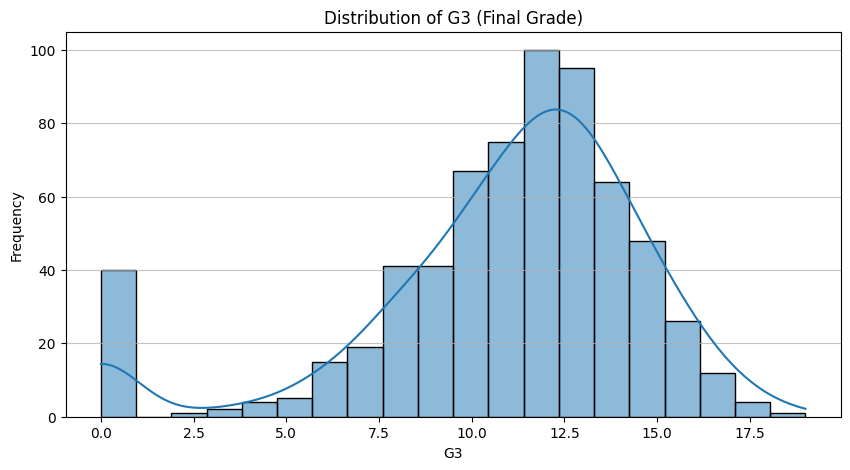

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of G3 using a histogram
plt.figure(figsize=(10, 5))
sns.histplot(df['G3'], bins=20, kde=True)
plt.title('Distribution of G3 (Final Grade)')
plt.xlabel('G3')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

Se puede ver que la distribucion es una campana de gauss y el valor mas frecuente esta entorno a 12

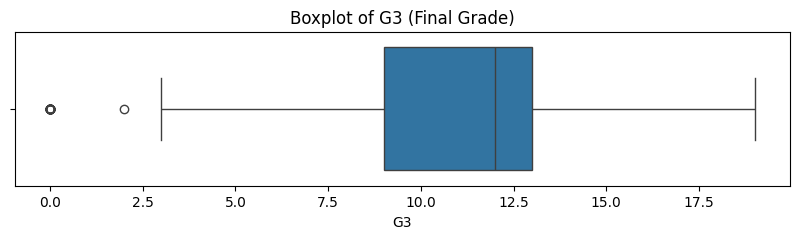

In [145]:
# Visualize the distribution of G3 using a boxplot for outliers and quartiles
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['G3'])
plt.title('Boxplot of G3 (Final Grade)')
plt.xlabel('G3')
plt.show()

Se puede observar que la mayoria de las puntuaciones estan muy concentradas entre el 10 y el 12.Hay algunos valores outliners.

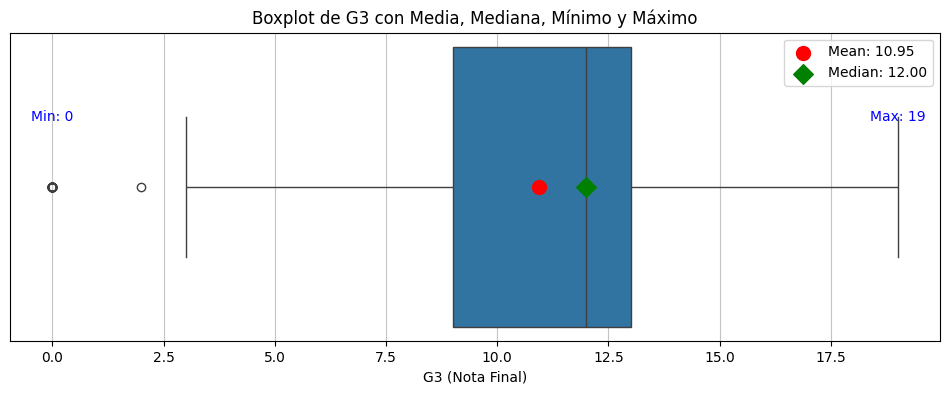

Descriptive statistics for G3:


,G3
count,660.000000
mean,10.948485
std,3.869700
min,0.000000
25%,9.000000
50%,12.000000
75%,13.000000
max,19.000000


In [146]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate descriptive statistics for G3
g3_stats = df['G3'].describe()
mean_g3 = g3_stats['mean']
median_g3 = g3_stats['50%']
min_g3 = g3_stats['min']
max_g3 = g3_stats['max']

plt.figure(figsize=(12, 4))
sns.boxplot(x=df['G3'])

# Add mean and median to the boxplot
plt.scatter(mean_g3, 0, color='red', marker='o', s=100, zorder=5, label=f'Mean: {mean_g3:.2f}')
plt.scatter(median_g3, 0, color='green', marker='D', s=100, zorder=5, label=f'Median: {median_g3:.2f}')

# Add min and max to the boxplot (already part of the whiskers, but explicitly marked for clarity)
plt.text(min_g3, -0.2, f'Min: {min_g3:.0f}', color='blue', ha='center', va='center')
plt.text(max_g3, -0.2, f'Max: {max_g3:.0f}', color='blue', ha='center', va='center')

plt.title('Boxplot de G3 con Media, Mediana, Mínimo y Máximo')
plt.xlabel('G3 (Nota Final)')
plt.yticks([]) # Hide y-axis ticks as it's a single boxplot
plt.legend()
plt.grid(axis='x', alpha=0.75)
plt.show()

print("Descriptive statistics for G3:")
display(g3_stats)

Se ven algunos valores de alumnos que tiraron la toalla, pero la distribucion esta bastante concrentrada, muchos aprobados justitos.

### ❓ Pregunta 1 — Primera impresión del dataset

Tras esta inspección inicial:
- ¿Cuántas filas y columnas tiene el dataset?
- ¿Qué tipo de problema de ML es este (clasificación o regresión)? ¿Por qué?
- ¿Cómo está distribuida la variable objetivo `G3`? ¿Hay sesgo hacia algún rango de notas?
- ¿Qué columnas crees que pueden ser más relevantes para predecir la nota final y por qué?

660,32 --El dataset tiene 660 filas y 32 columnas.
Es un problema de regresion ya que tratamos de predecir un numeroo no clasificar por grupos .Es una distribucion continua y se trata de predecir una nota en un continuo.
hay cierto sesgo hacia valores centrales entorno al aprobado.es dificil suspender y tambien sacar buenas notas pero facil aprobar.Probablemente las notas previas sean buen predictor y el tiempo de estudio tambien seguramente.Segun la matriz de correlacion el alcohol del finde tambien influye y los suspensos previos.


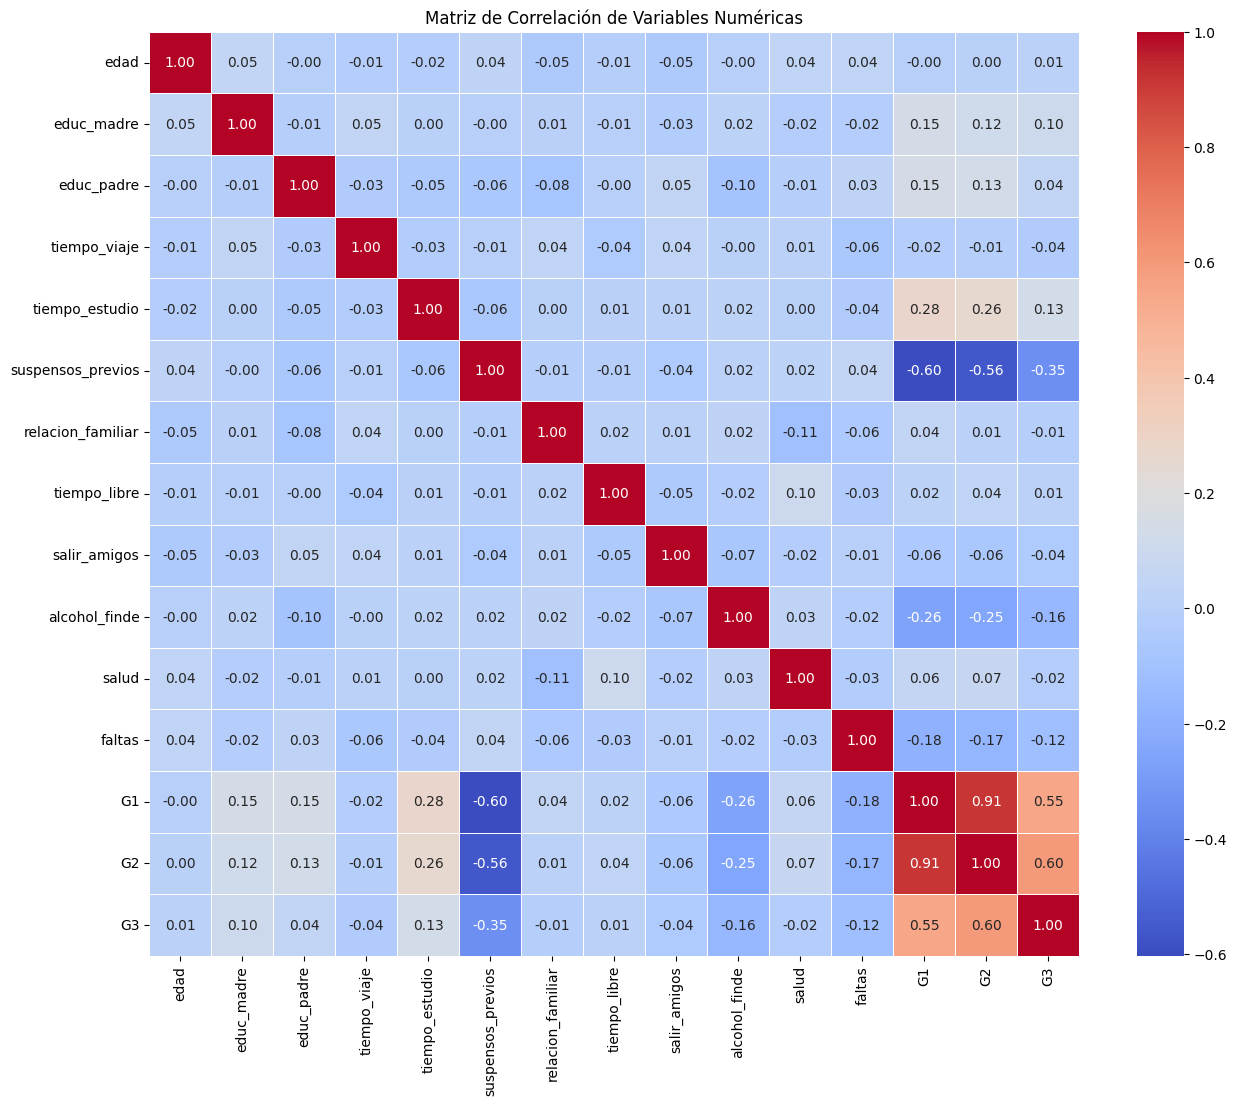

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Seleccionar solo las columnas numéricas para la matriz de correlación
numeric_df = df.select_dtypes(include=[np.number])

# Calcular la matriz de correlación
correlation_matrix = numeric_df.corr()

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()


---

## 2. 🎨 Análisis Exploratorio de Datos (EDA)

🚩 **Esta es la fase con más peso de toda la actividad.** Aquí se valora especialmente la **profundidad** de tu análisis y **lo que extraigas de los gráficos**, no la cantidad de gráficos.

Genera al menos los siguientes tipos de visualizaciones (puedes añadir más si lo crees necesario):
- Distribución de la **variable objetivo `G3`** (histograma, boxplot…).
- Distribución de las **variables numéricas** (histogramas, boxplots…).
- Distribución de las **variables categóricas** (gráficos de barras / sectores).
- **Relación entre variables y `G3`** (qué variables parecen influir más en la nota).
- **Mapa de correlaciones** entre variables numéricas.

> 💡 *Cada gráfico que pongas debe responder a una pregunta. Si no se te ocurre la pregunta, probablemente ese gráfico sobra.*

In [148]:
# 2.1 Análisis de la distribución de la variable objetivo G3.
#     Elige el gráfico que muestre mejor cómo se reparten las notas.


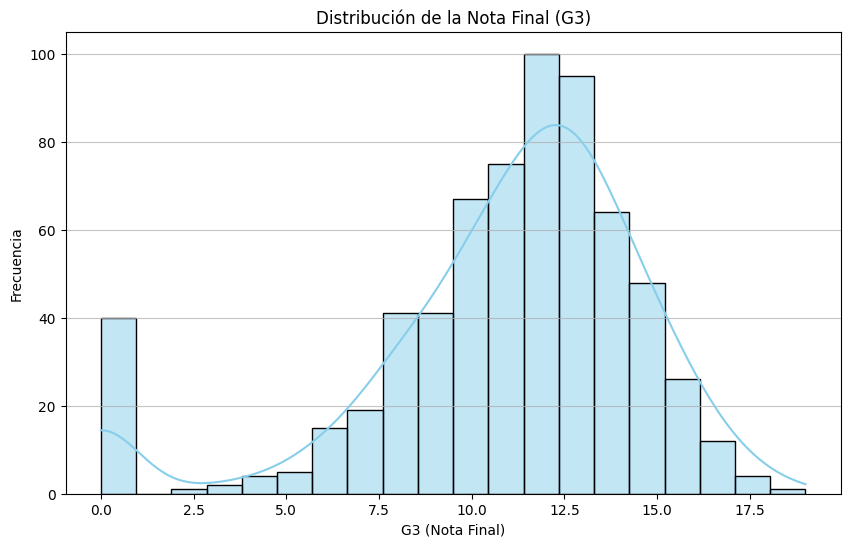

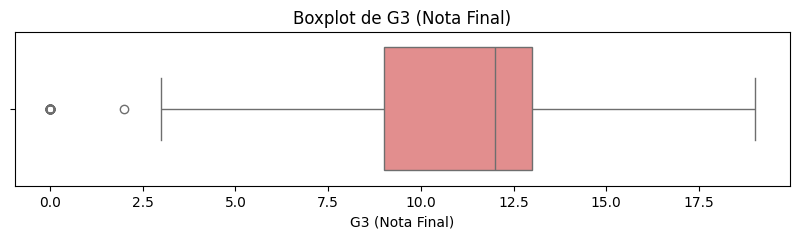

In [149]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma de la variable objetivo G3
plt.figure(figsize=(10, 6))
sns.histplot(df['G3'], bins=20, kde=True, color='skyblue')
plt.title('Distribución de la Nota Final (G3)')
plt.xlabel('G3 (Nota Final)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Un boxplot también es útil para complementar y ver outliers
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['G3'], color='lightcoral')
plt.title('Boxplot de G3 (Nota Final)')
plt.xlabel('G3 (Nota Final)')
plt.show()


Con el diagrama de barras y bigotes y el histograma se ve muy bien.

### ❓ Pregunta 2 — Distribución de la variable objetivo

- ¿Qué gráfico has elegido para visualizar la distribución de `G3`? ¿Por qué?
- ¿Sigue una distribución aproximadamente normal o está sesgada?
- ¿Hay algún valor que aparece con una frecuencia inusual (por ejemplo, muchos 0)? ¿A qué crees que se debe? ¿Qué consecuencias puede tener sobre el modelo?

Histograma y bigotes explican muy bien lo centralizados que estan los datos. es una distribucion normal, hay algunos outliners pero son pocos , probablemente de abbandonos.Puede sesgar el modelo pero habra que normalizarlos

In [150]:
# 2.2 Distribuciones de las variables NUMÉRICAS.
#     Histogramas, boxplots o lo que consideres adecuado.
#     Fíjate en posibles outliers y formas de las distribuciones.


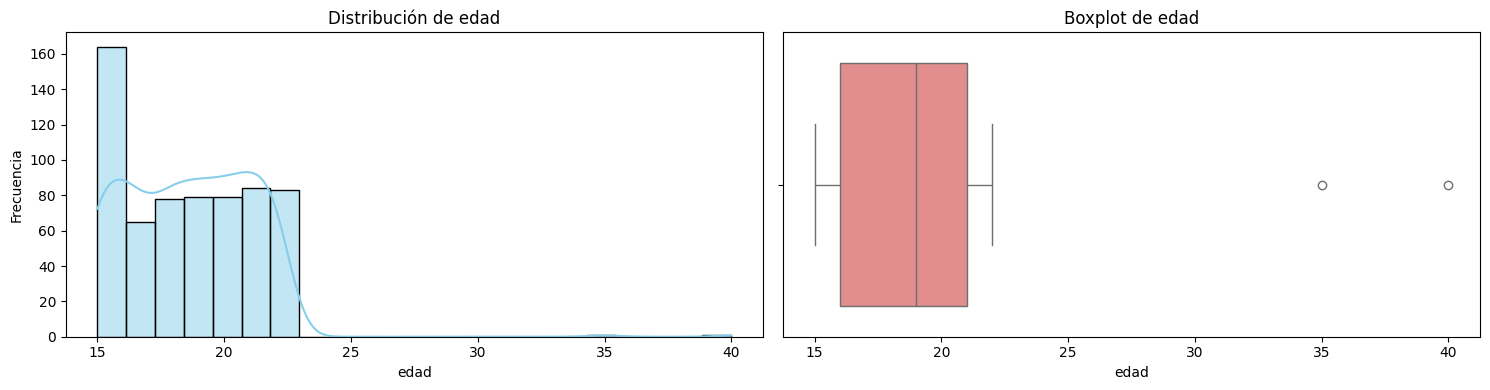


Estadísticas descriptivas para edad:


,edad
count,634.000000
mean,18.608833
std,2.558321
min,15.000000
25%,16.000000
50%,19.000000
75%,21.000000
max,40.000000


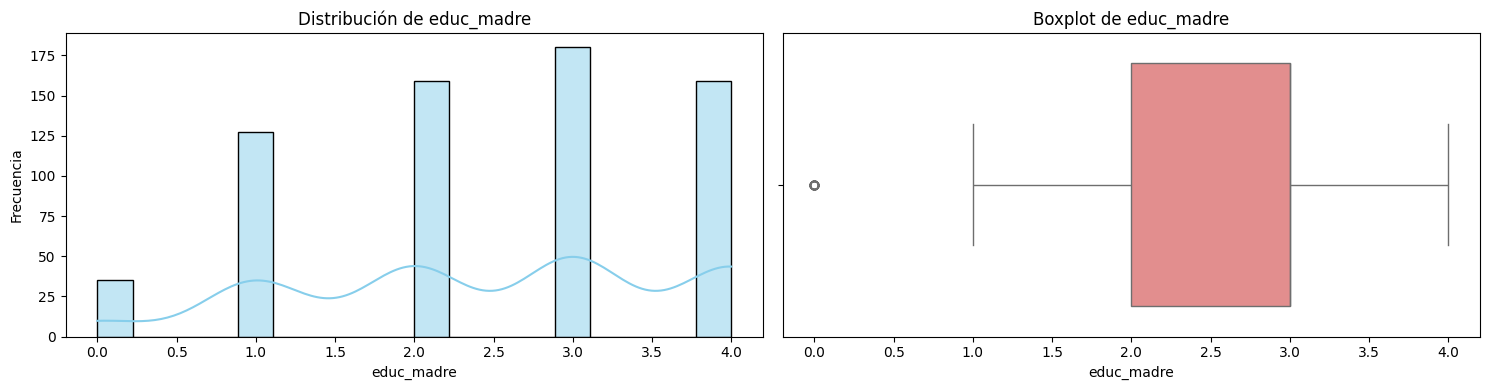


Estadísticas descriptivas para educ_madre:


,educ_madre
count,660.000000
mean,2.456061
std,1.197953
min,0.000000
25%,2.000000
50%,3.000000
75%,3.000000
max,4.000000


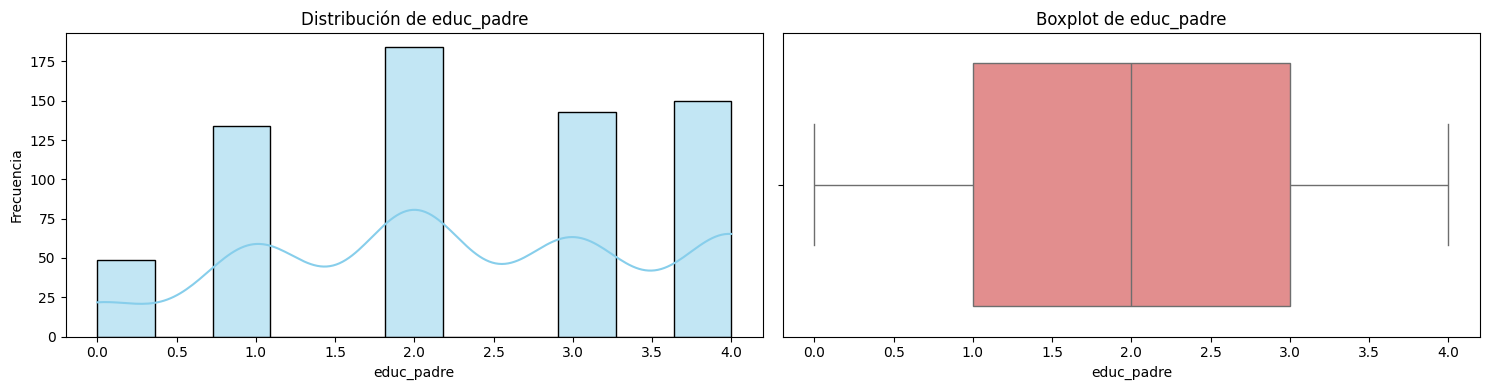


Estadísticas descriptivas para educ_padre:


,educ_padre
count,660.000000
mean,2.319697
std,1.235258
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,4.000000


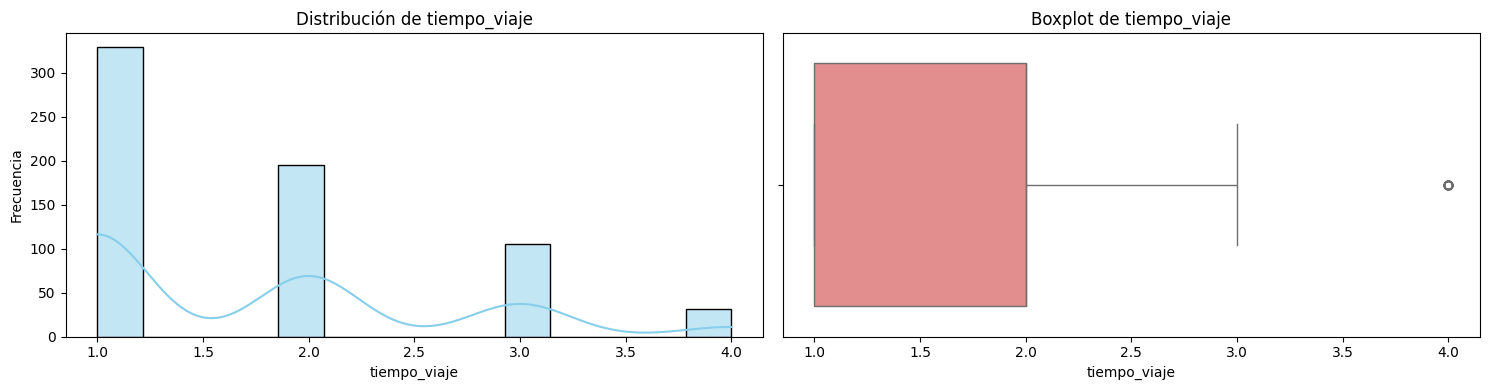


Estadísticas descriptivas para tiempo_viaje:


,tiempo_viaje
count,660.000000
mean,1.754545
std,0.886791
min,1.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,4.000000


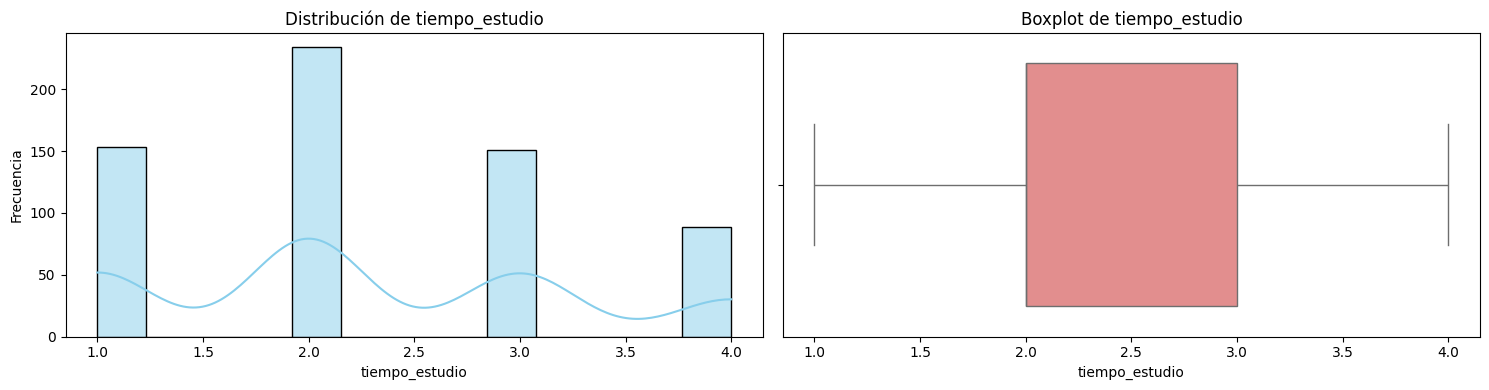


Estadísticas descriptivas para tiempo_estudio:


,tiempo_estudio
count,627.000000
mean,2.280702
std,0.987620
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,4.000000


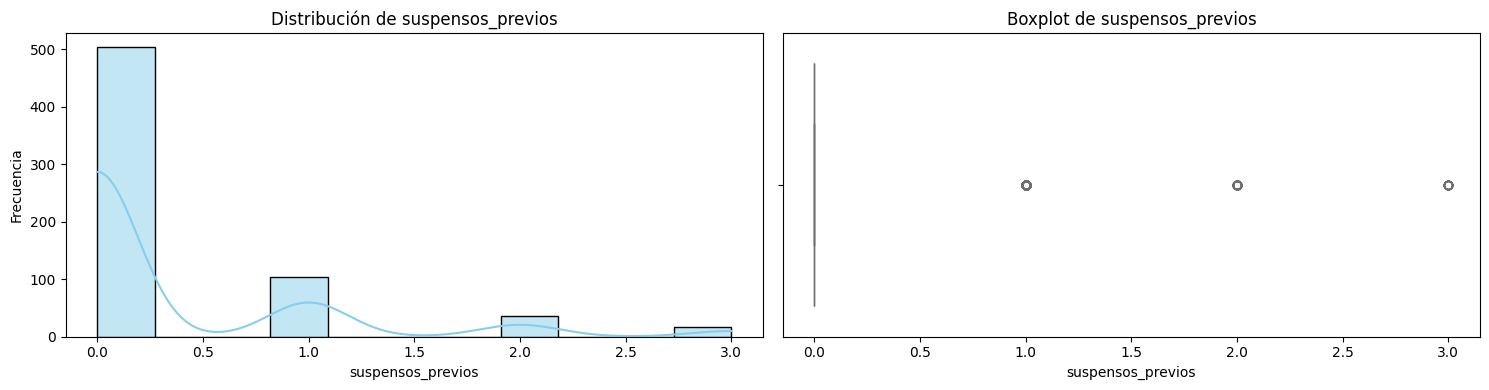


Estadísticas descriptivas para suspensos_previos:


,suspensos_previos
count,660.000000
mean,0.343939
std,0.700017
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,3.000000


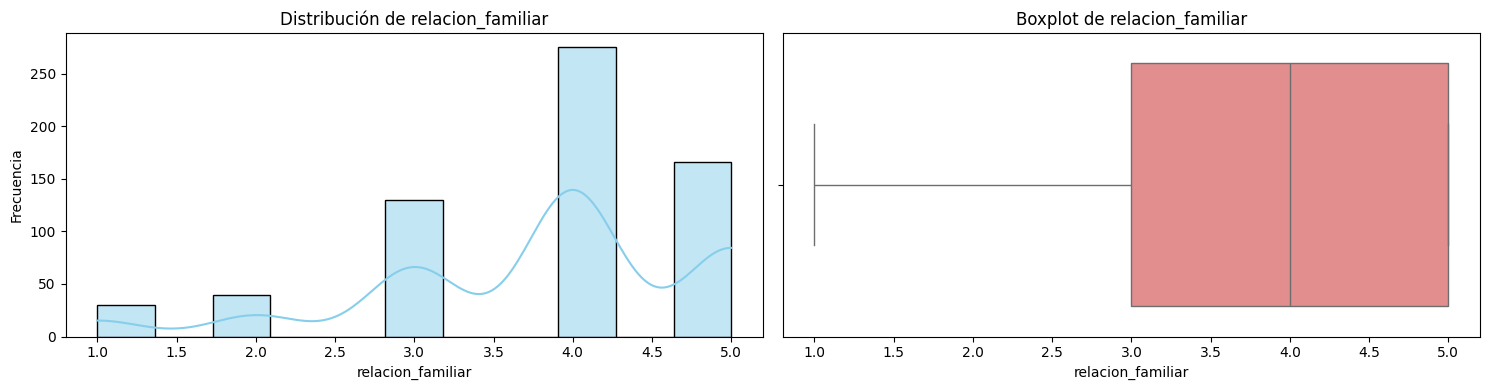


Estadísticas descriptivas para relacion_familiar:


,relacion_familiar
count,641.000000
mean,3.790952
std,1.044321
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


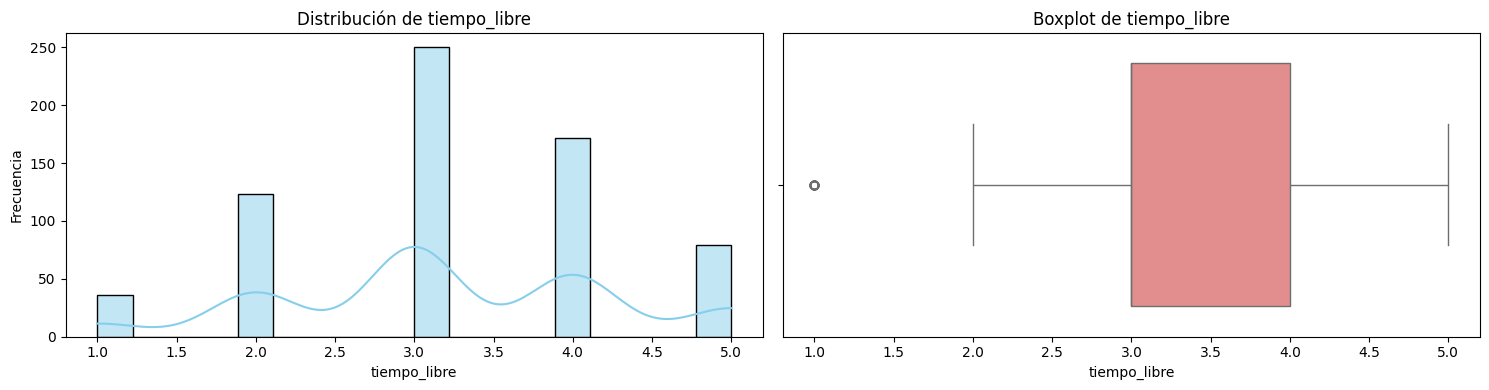


Estadísticas descriptivas para tiempo_libre:


,tiempo_libre
count,660.000000
mean,3.204545
std,1.050606
min,1.000000
25%,3.000000
50%,3.000000
75%,4.000000
max,5.000000


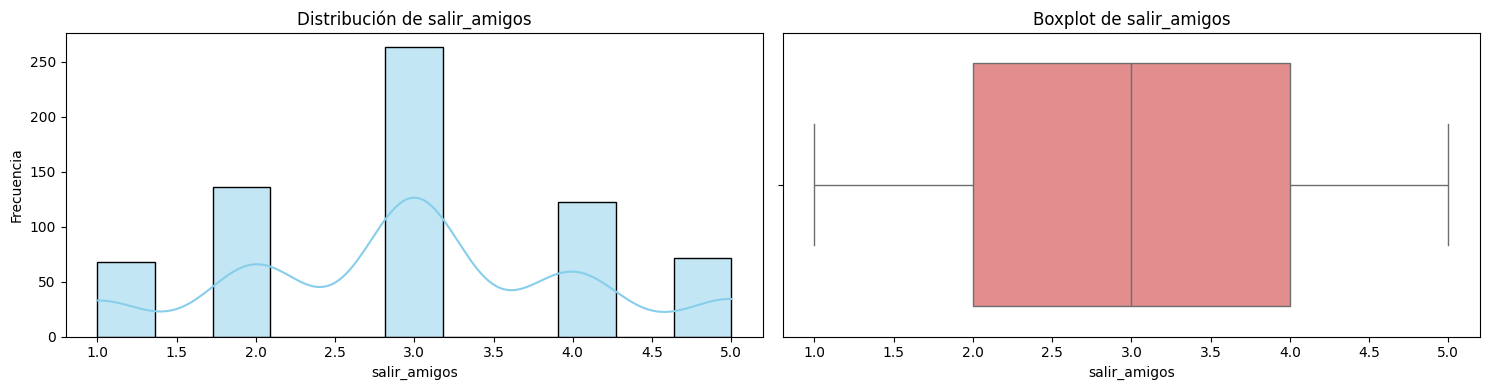


Estadísticas descriptivas para salir_amigos:


,salir_amigos
count,660.000000
mean,2.987879
std,1.111332
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


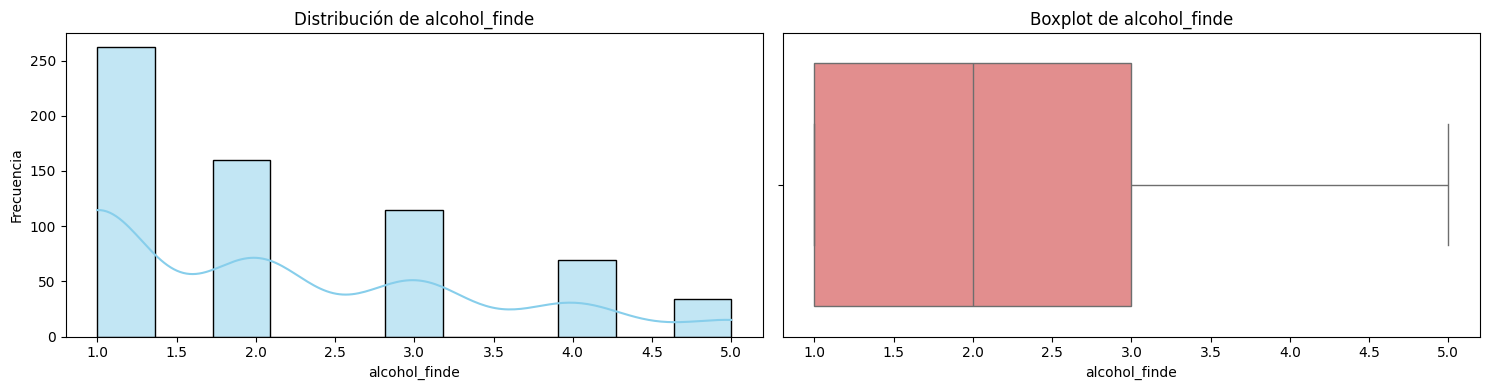


Estadísticas descriptivas para alcohol_finde:


,alcohol_finde
count,640.000000
mean,2.145313
std,1.216402
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,5.000000


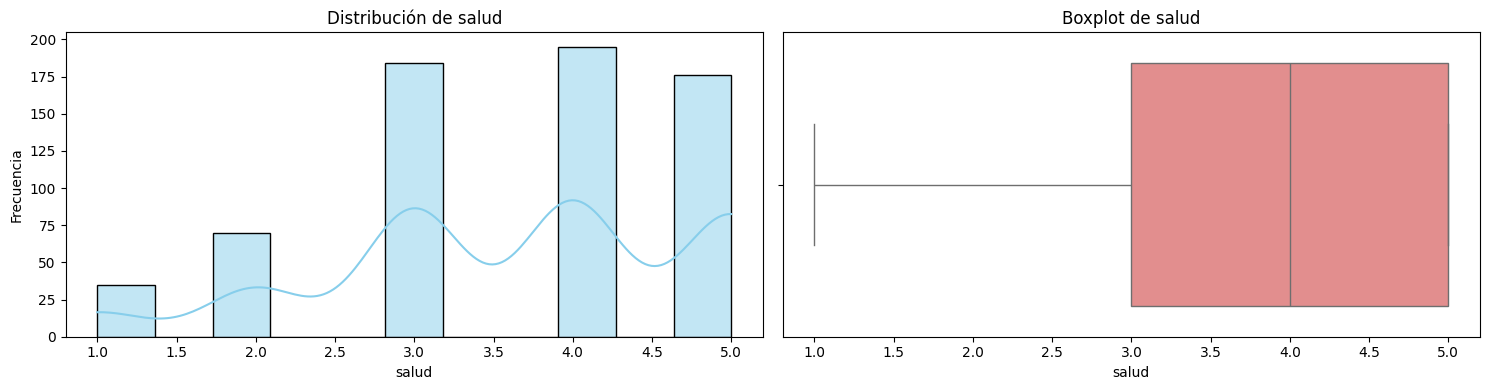


Estadísticas descriptivas para salud:


,salud
count,660.000000
mean,3.616667
std,1.141051
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


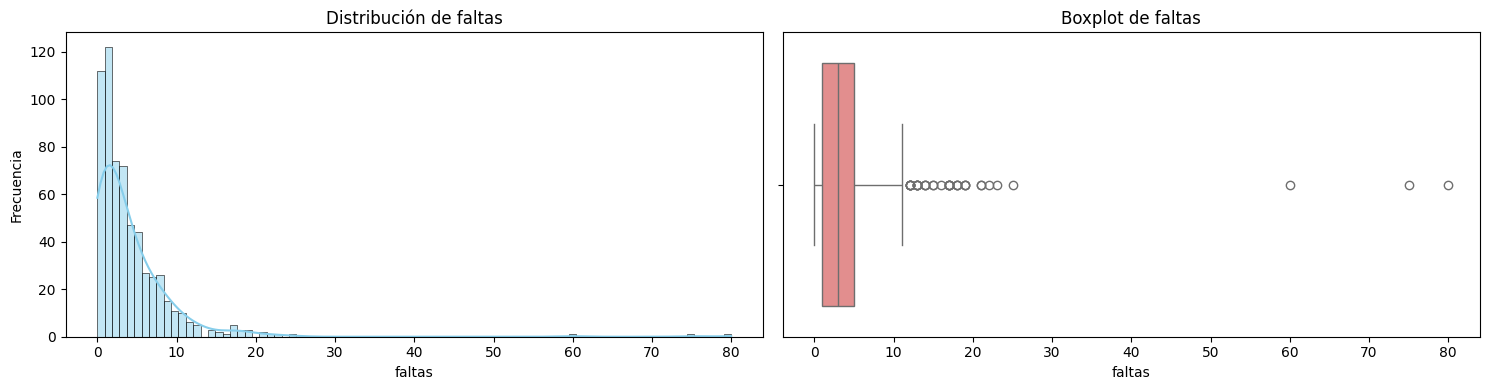


Estadísticas descriptivas para faltas:


,faltas
count,621.000000
mean,4.093398
std,6.292159
min,0.000000
25%,1.000000
50%,3.000000
75%,5.000000
max,80.000000


In [151]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Seleccionar solo las columnas numéricas
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Excluir G1, G2, G3 de este análisis de distribución general
# ya que ya se han analizado o se analizarán más a fondo con G3
# o para evitar la redundancia si el usuario quiere enfocarse en otras variables
# Esto puede ajustarse si el usuario desea incluirlas.
numeric_cols_to_plot = [col for col in numeric_cols if col not in ['G1', 'G2', 'G3']]

for col in numeric_cols_to_plot:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    # Histograma
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribución de {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frecuencia')

    # Boxplot
    sns.boxplot(x=df[col].dropna(), ax=axes[1], color='lightcoral')
    axes[1].set_title(f'Boxplot de {col}')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

    print(f"\nEstadísticas descriptivas para {col}:")
    display(df[col].describe())


In [152]:
# 2.3 Distribuciones de las variables CATEGÓRICAS.
#     ¿Hay categorías muy minoritarias? ¿Hay categorías mal escritas?


Análisis de Variables Categóricas:


--- Variable: escuela ---


,count
escuela,
IES_Cervantes,442
IES_Lorca,218


/tmp/ipykernel_5318/3663121469.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=value_counts.index, palette='viridis')


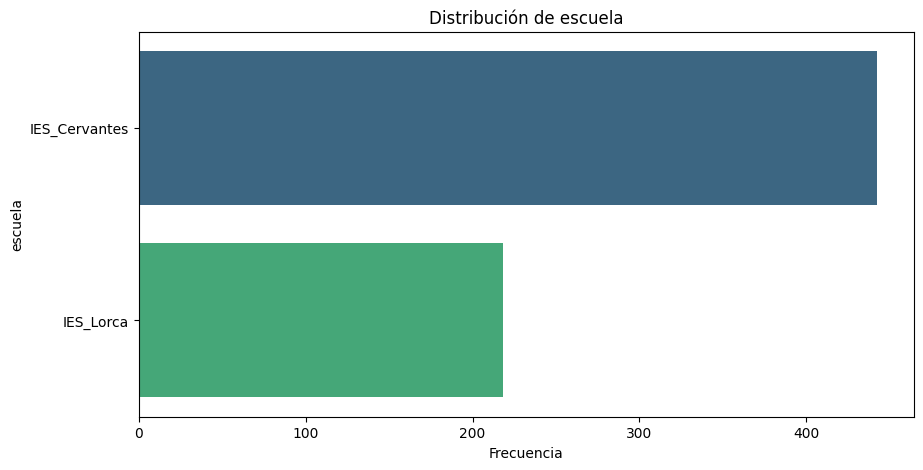


--- Variable: sexo ---


,count
sexo,
M,317
F,312
m,17
f,14


  ⚠️ Posibles categorías minoritarias (menos del 5%):
sexo
m    17
f    14
Name: count, dtype: int64


/tmp/ipykernel_5318/3663121469.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=value_counts.index, palette='viridis')


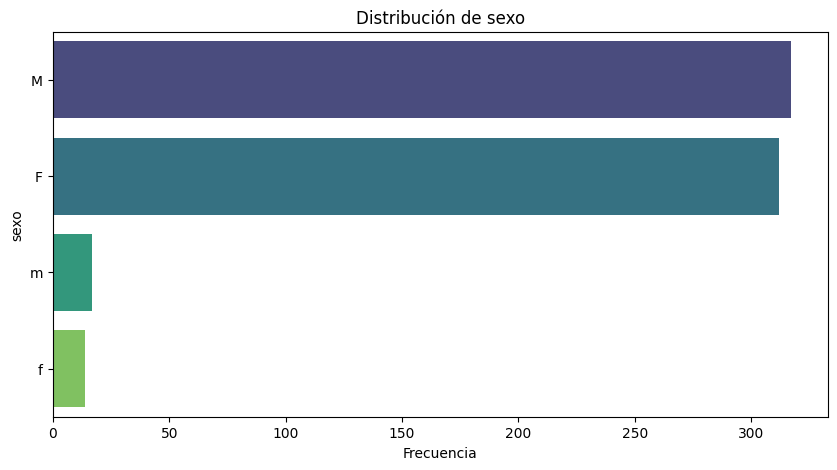


--- Variable: direccion ---


,count
direccion,
Urbana,480
Rural,180


/tmp/ipykernel_5318/3663121469.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=value_counts.index, palette='viridis')


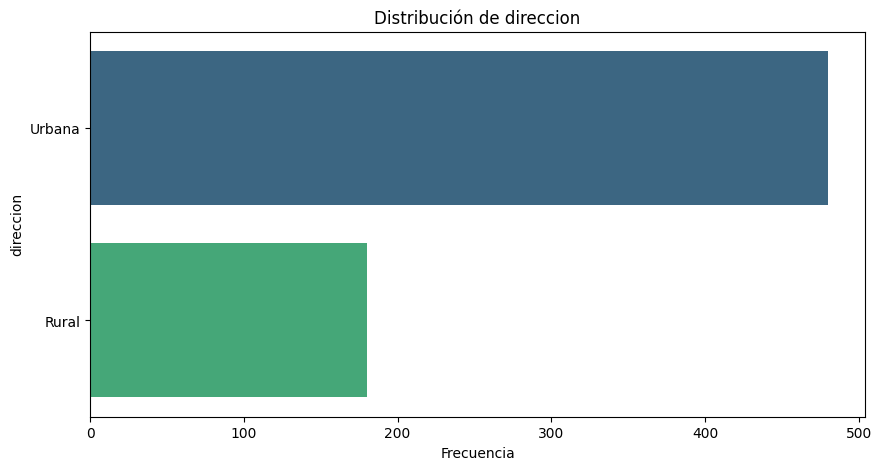


--- Variable: tamano_familia ---


,count
tamano_familia,
GT3,469
LE3,191


/tmp/ipykernel_5318/3663121469.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=value_counts.index, palette='viridis')


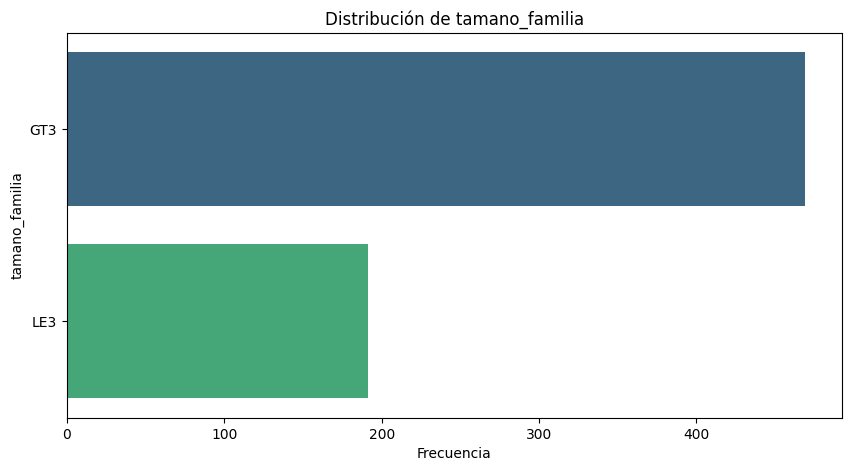


--- Variable: estado_padres ---


,count
estado_padres,
Juntos,556
Separados,104


/tmp/ipykernel_5318/3663121469.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=value_counts.index, palette='viridis')


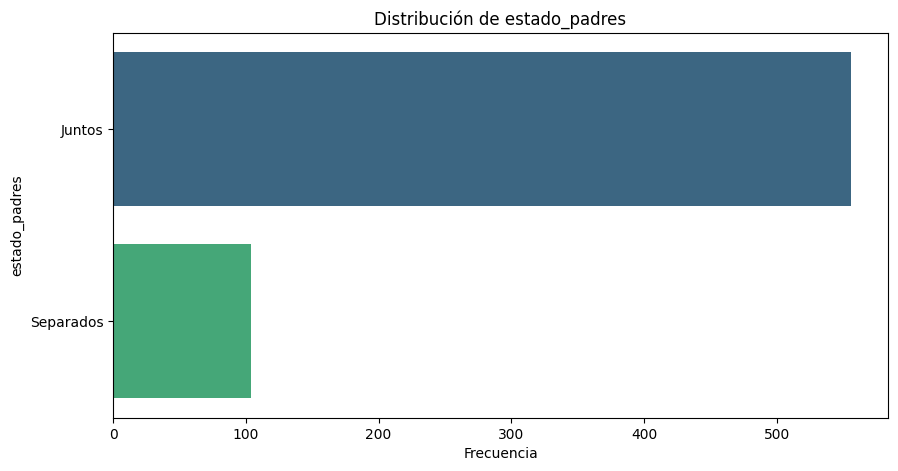


--- Variable: trabajo_madre ---


,count
trabajo_madre,
hogar,140
servicios,134
otro,132
sanidad,130
profesora,124


/tmp/ipykernel_5318/3663121469.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=value_counts.index, palette='viridis')


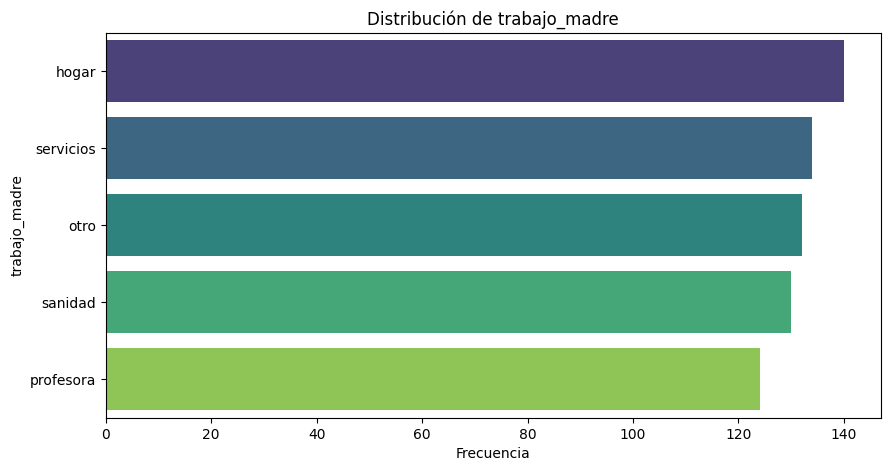


--- Variable: trabajo_padre ---


,count
trabajo_padre,
sanidad,144
profesor,133
otro,132
servicios,127
hogar,124


/tmp/ipykernel_5318/3663121469.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=value_counts.index, palette='viridis')


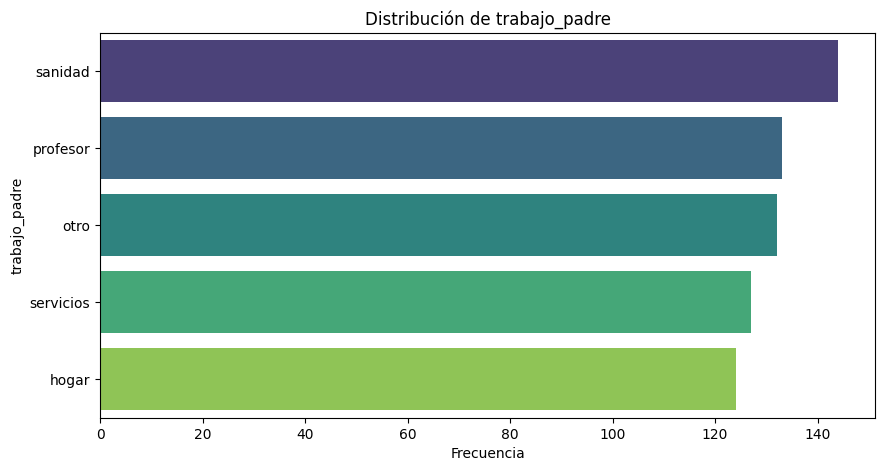


--- Variable: razon_eleccion ---


,count
razon_eleccion,
cerca_casa,176
reputacion,170
cursos,159
otro,155


/tmp/ipykernel_5318/3663121469.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=value_counts.index, palette='viridis')


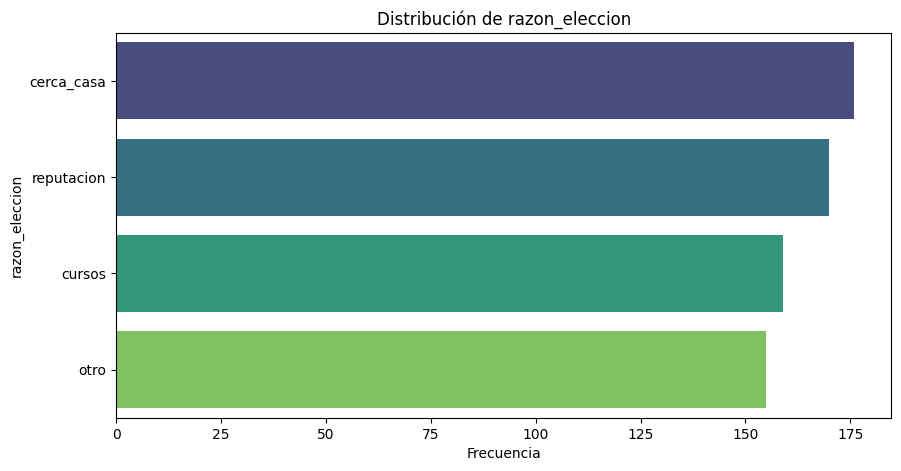


--- Variable: tutor ---


,count
tutor,
otro,224
padre,222
madre,214


/tmp/ipykernel_5318/3663121469.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=value_counts.index, palette='viridis')


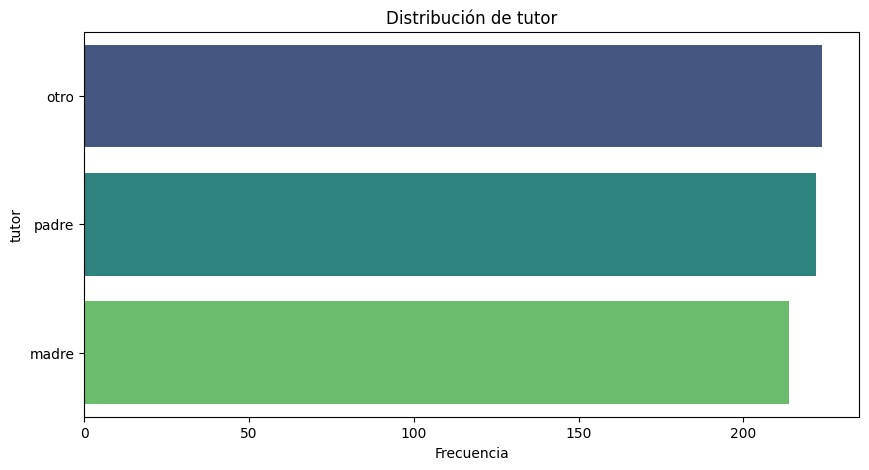


--- Variable: apoyo_escolar ---


,count
apoyo_escolar,
no,533
si,112
SI,15


  ⚠️ Posibles categorías minoritarias (menos del 5%):
apoyo_escolar
SI    15
Name: count, dtype: int64


/tmp/ipykernel_5318/3663121469.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=value_counts.index, palette='viridis')


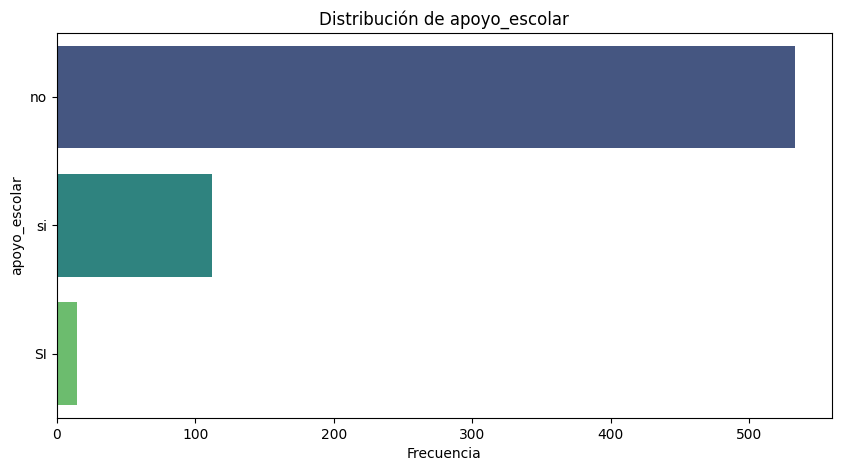


--- Variable: apoyo_familiar ---


,count
apoyo_familiar,
si,384
no,233
NaN,32
si,11


  ⚠️ Posibles categorías minoritarias (menos del 5%):
apoyo_familiar
si     11
Name: count, dtype: int64


/tmp/ipykernel_5318/3663121469.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=value_counts.index, palette='viridis')


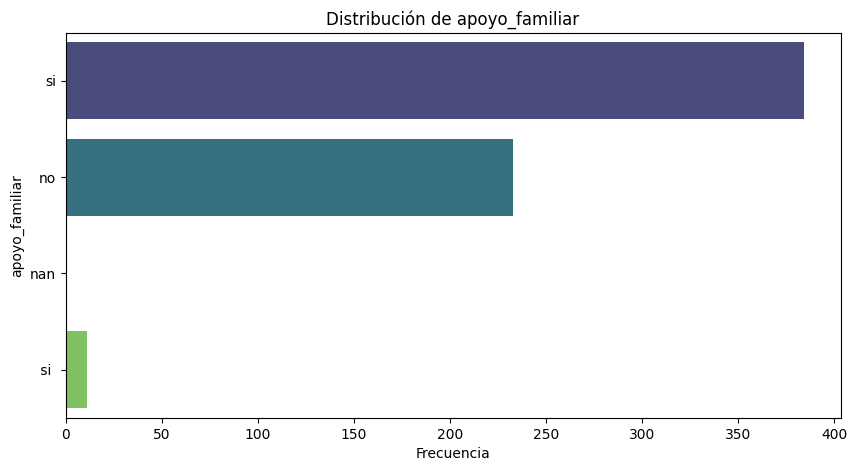


--- Variable: clases_extra_pagadas ---


,count
clases_extra_pagadas,
no,373
si,287


/tmp/ipykernel_5318/3663121469.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=value_counts.index, palette='viridis')


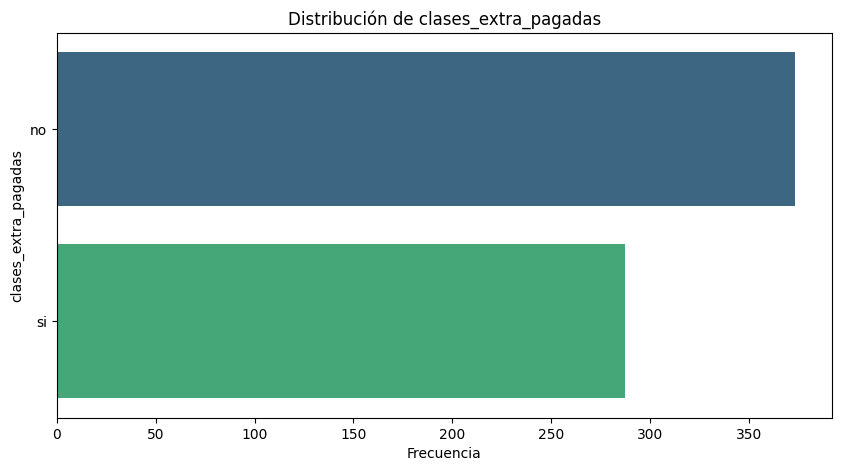


--- Variable: actividades ---


,count
actividades,
si,332
no,328


/tmp/ipykernel_5318/3663121469.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=value_counts.index, palette='viridis')


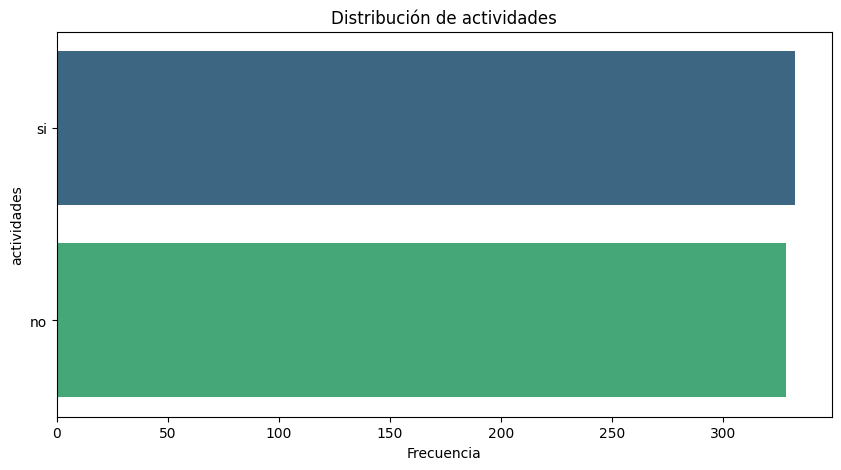


--- Variable: guarderia ---


,count
guarderia,
si,531
no,129


/tmp/ipykernel_5318/3663121469.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=value_counts.index, palette='viridis')


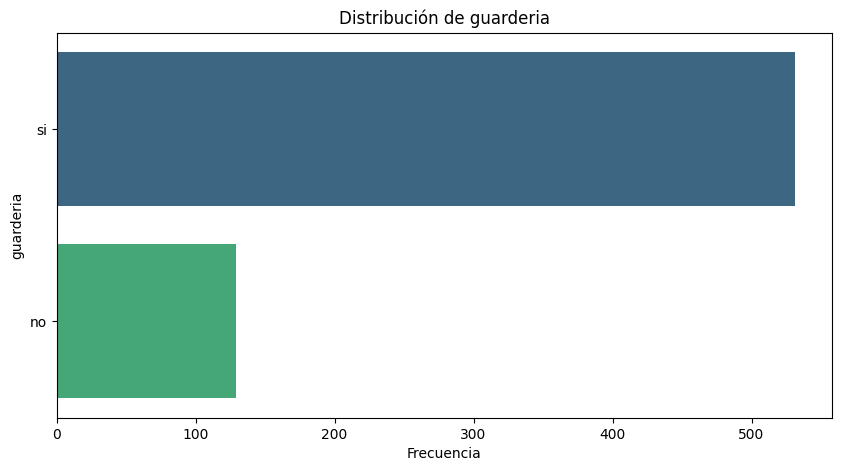


--- Variable: quiere_universidad ---


,count
quiere_universidad,
si,616
no,44


/tmp/ipykernel_5318/3663121469.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=value_counts.index, palette='viridis')


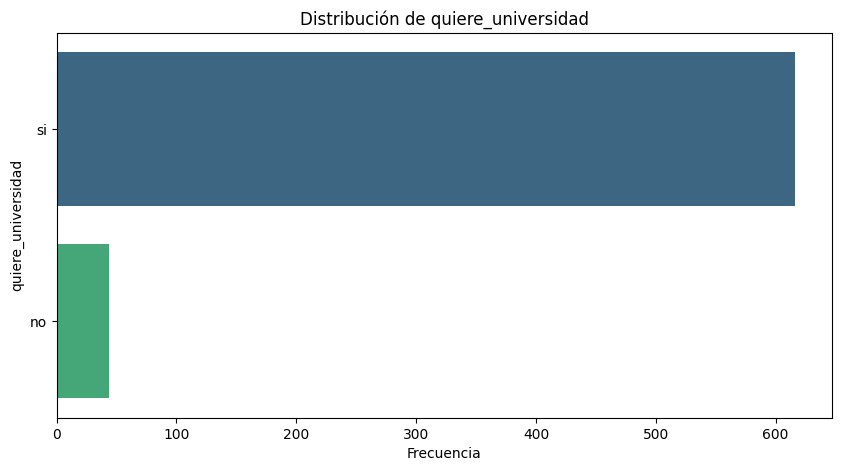


--- Variable: internet ---


,count
internet,
si,551
no,97
NO,12


  ⚠️ Posibles categorías minoritarias (menos del 5%):
internet
NO    12
Name: count, dtype: int64


/tmp/ipykernel_5318/3663121469.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=value_counts.index, palette='viridis')


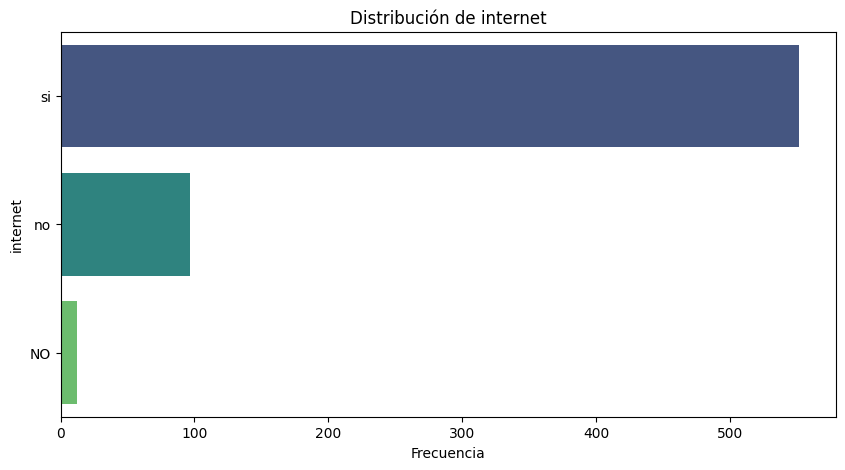


--- Variable: relacion_pareja ---


,count
relacion_pareja,
no,436
si,224


/tmp/ipykernel_5318/3663121469.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=value_counts.index, palette='viridis')


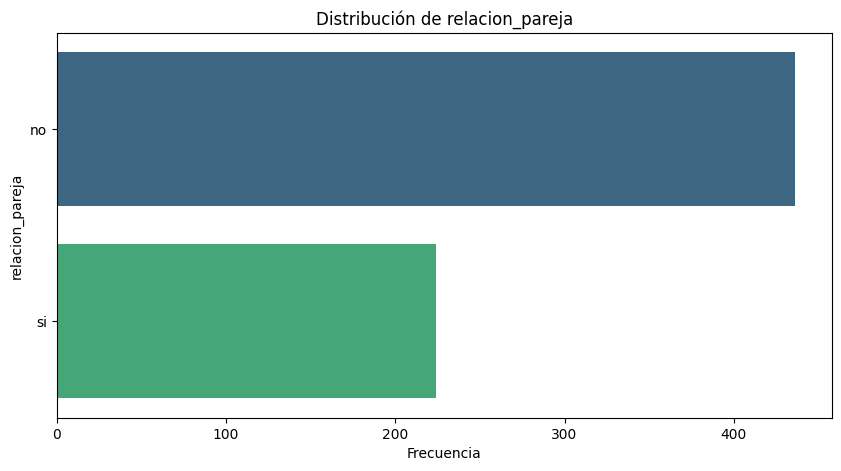

In [153]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las columnas categóricas
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Análisis de Variables Categóricas:\n")

for col in categorical_cols:
    print(f"\n--- Variable: {col} ---")
    value_counts = df[col].value_counts(dropna=False)
    display(value_counts)

    # Identificar categorías minoritarias
    # Consideramos minoritarias si representan menos del 5% de los datos
    total_rows = len(df[col].dropna())
    if total_rows > 0:
        minority_threshold = 0.05 * total_rows
        minority_categories = value_counts[value_counts < minority_threshold]
        if not minority_categories.empty:
            print(f"  ⚠️ Posibles categorías minoritarias (menos del 5%):\n{minority_categories}")

    # Comprobar si hay muchos valores únicos, lo que podría indicar errores tipográficos
    num_unique = df[col].nunique()
    if num_unique > 20: # Un umbral arbitrario, se puede ajustar
        print(f"  ❗ Atención: Esta columna tiene {num_unique} valores únicos. Podría indicar categorías mal escritas o que no es categórica.")

    # Visualizar la distribución de la variable categórica
    plt.figure(figsize=(10, 5))
    sns.countplot(y=col, data=df, order=value_counts.index, palette='viridis')
    plt.title(f'Distribución de {col}')
    plt.xlabel('Frecuencia')
    plt.ylabel(col)
    plt.show()


En general la distribucion esta bien aunque hay que normalizar variables ya que parece que hay algunas como sexo que estan mal escritas.


In [154]:
# 2.4 Relación de cada variable con la nota final G3.
#     Algunas ideas:
#     - Boxplots de G3 por cada variable categórica (sexo, escuela, internet…).
#     - Scatter plots de G3 frente a variables numéricas (G1, G2, faltas, edad…).
#     - Comparar la nota media entre grupos (con/sin apoyo familiar, etc.).


Generando Boxplots de G3 por Variables Categóricas...


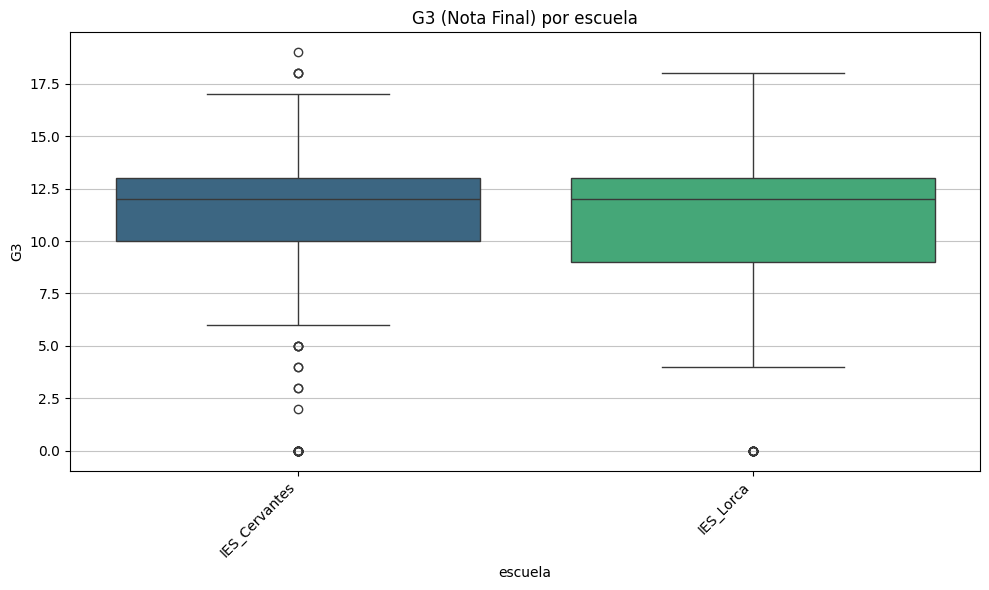

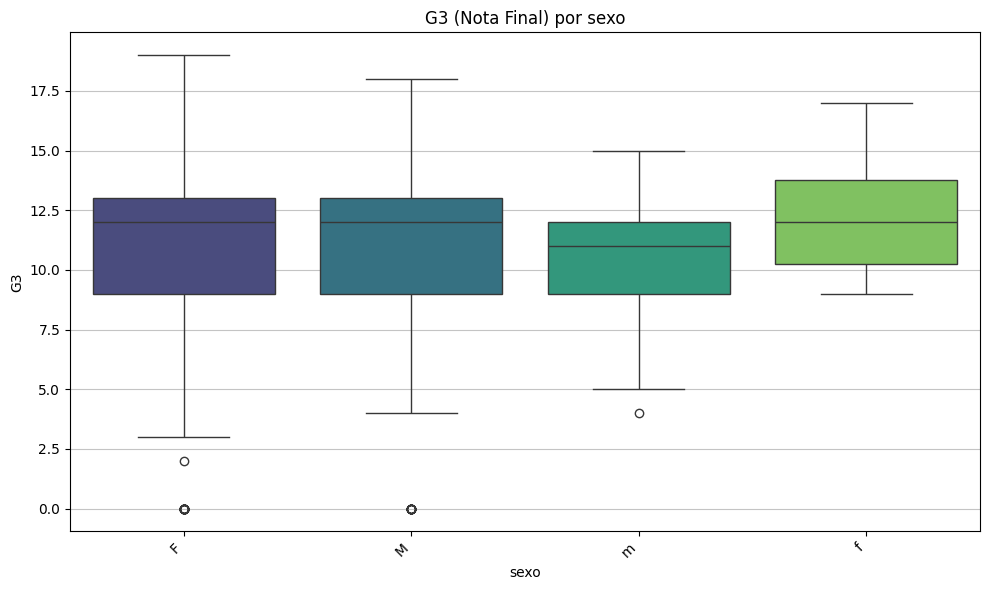

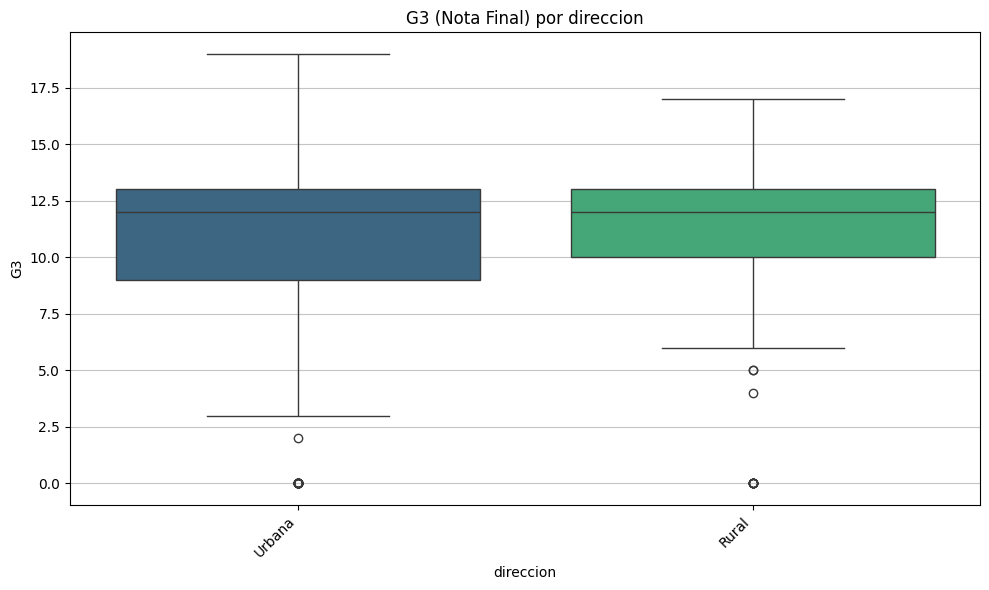

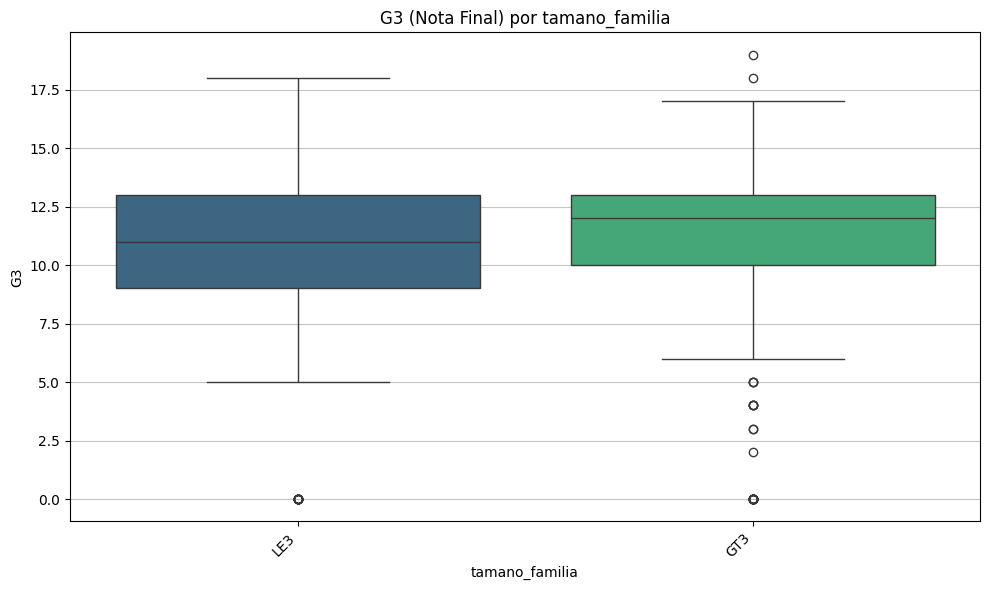

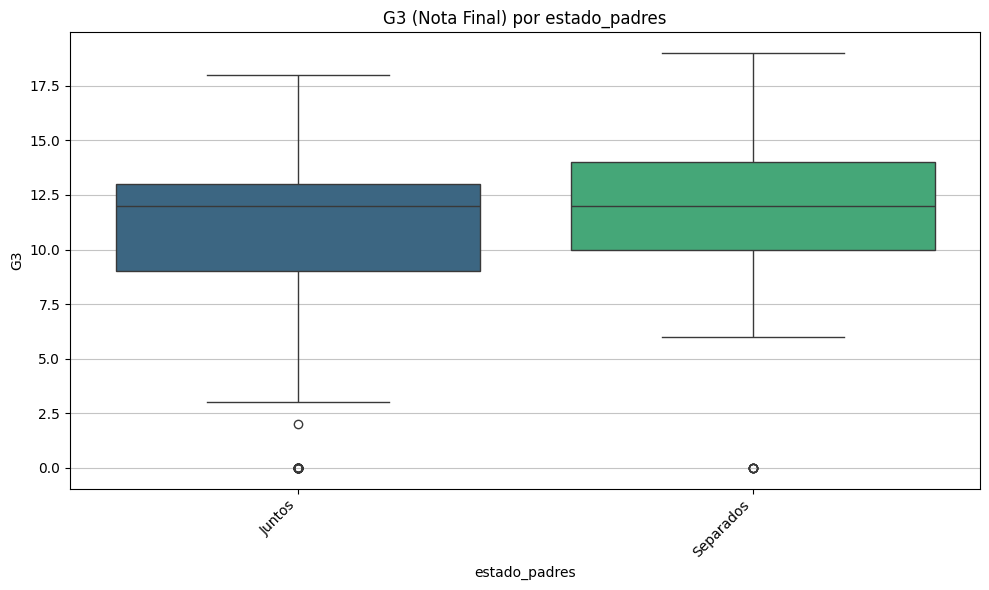

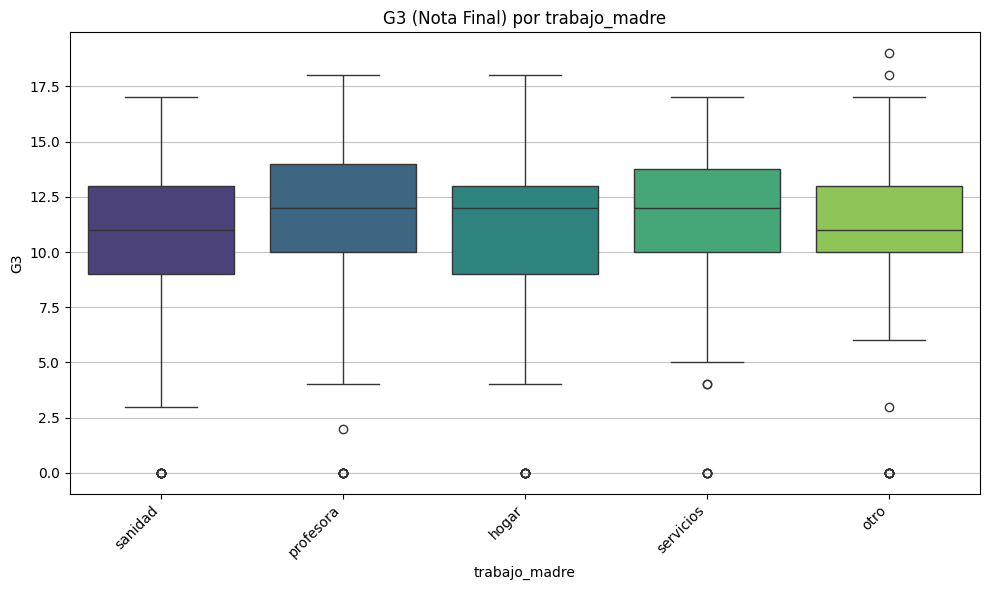

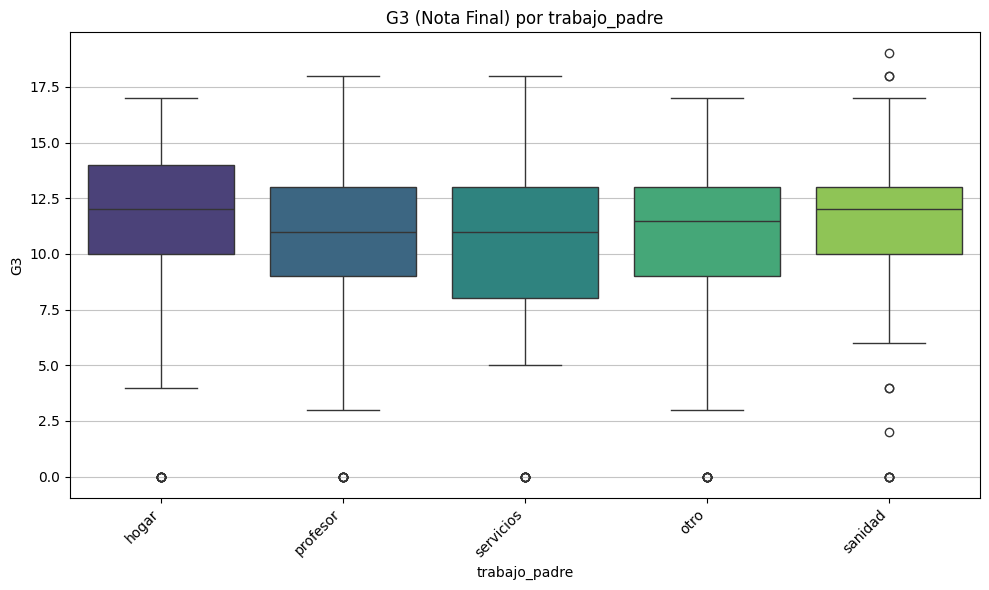

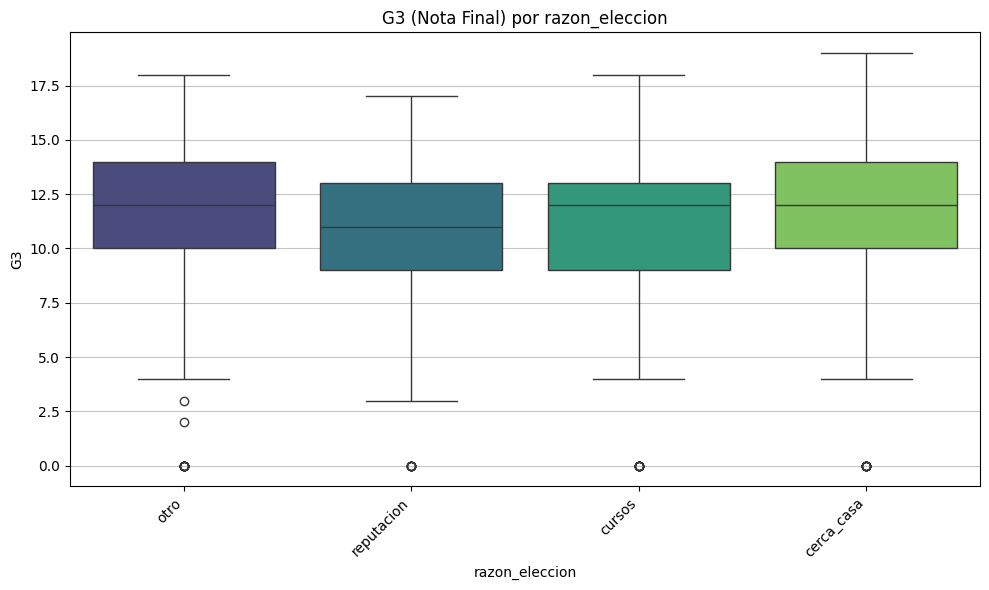

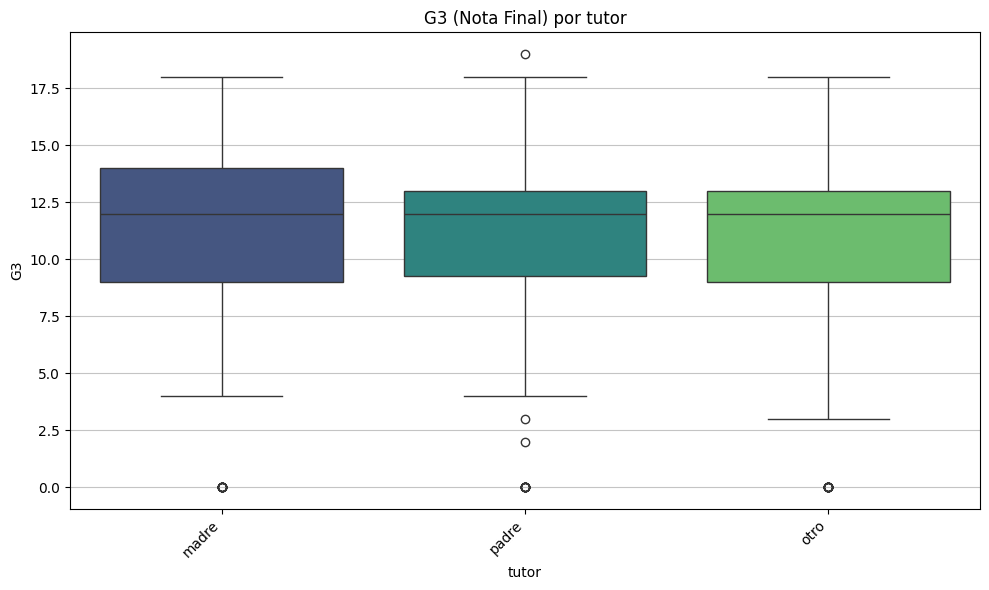

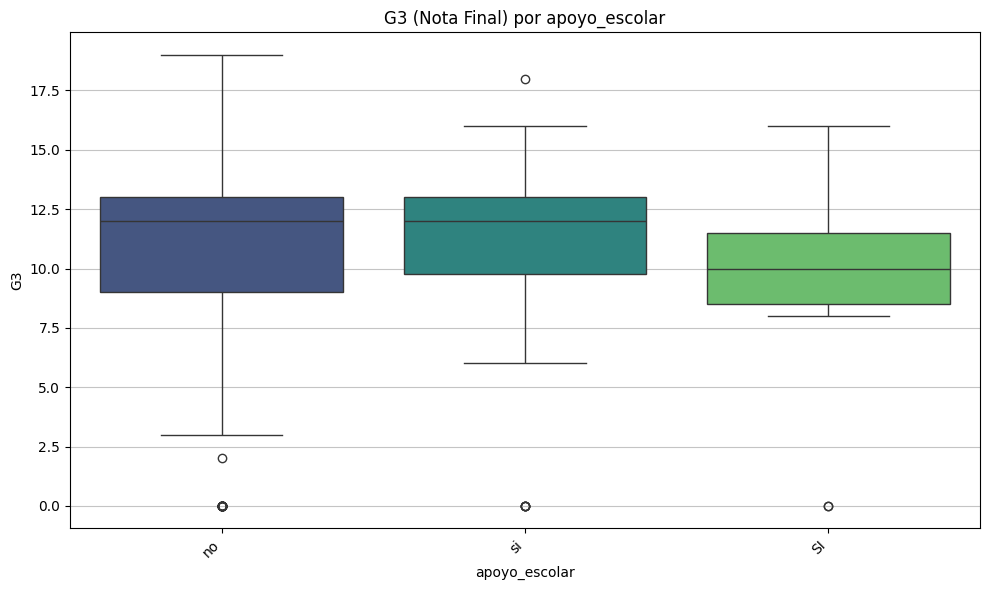

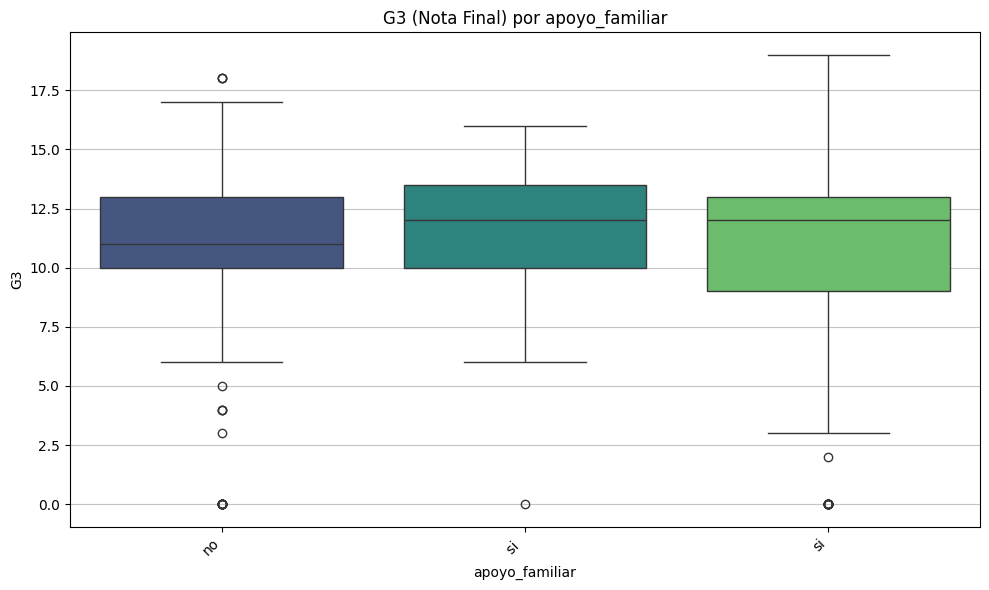

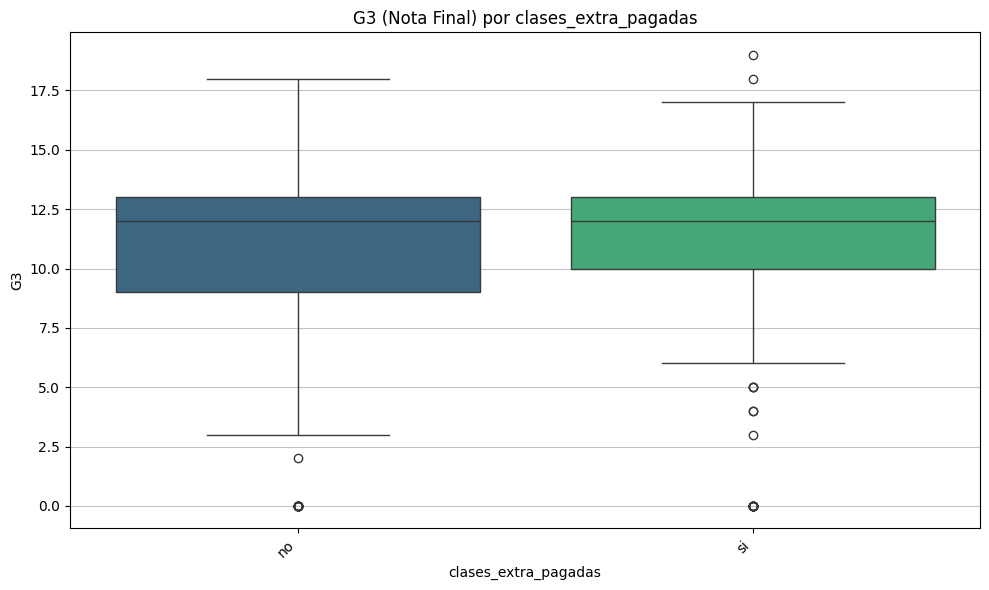

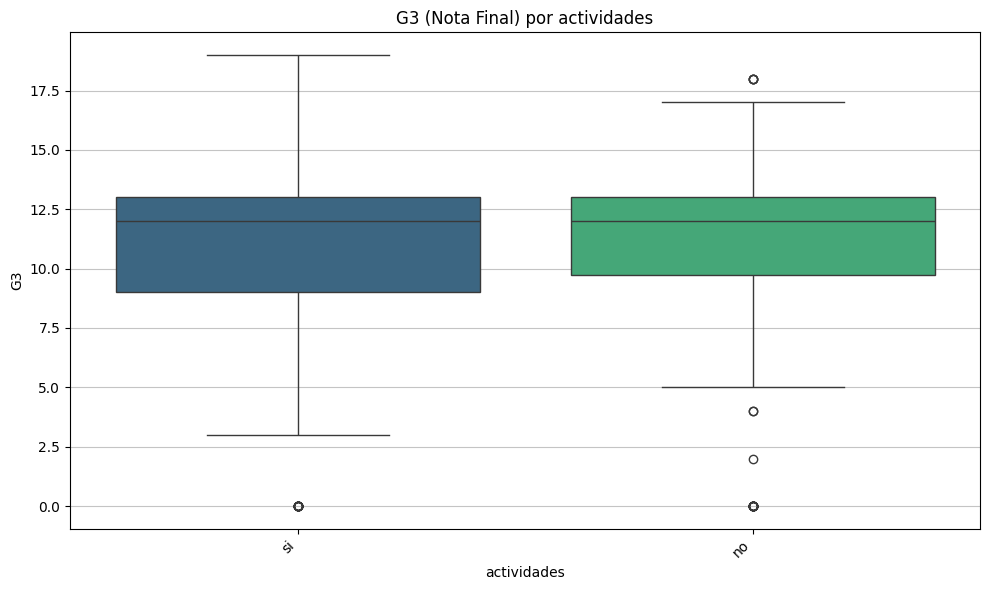

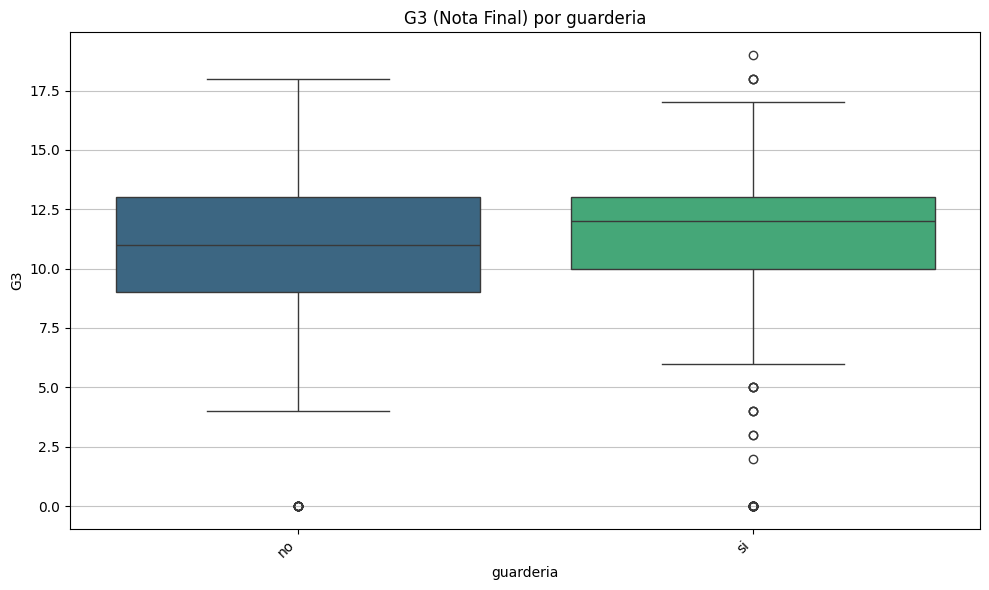

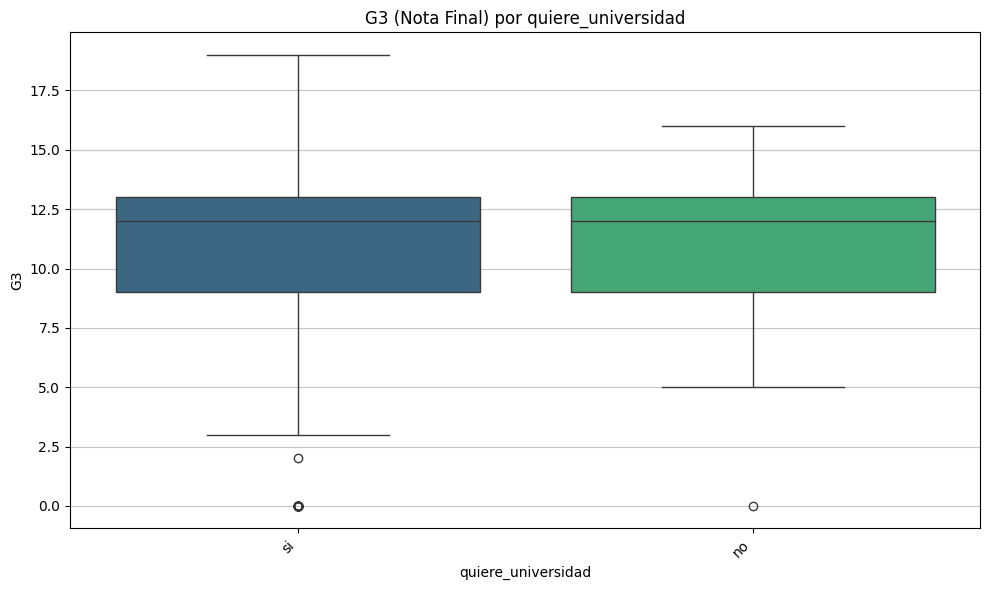

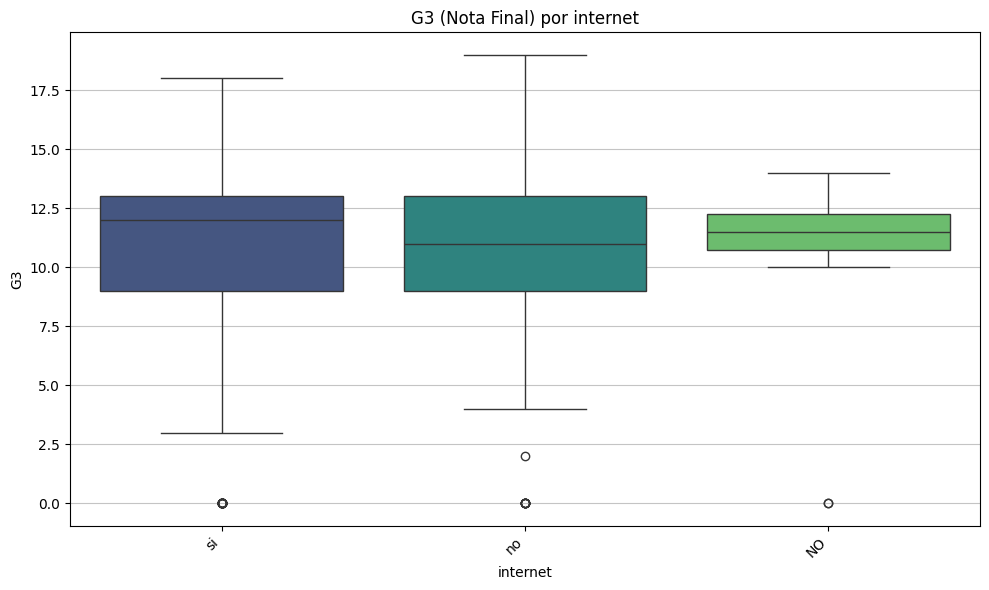

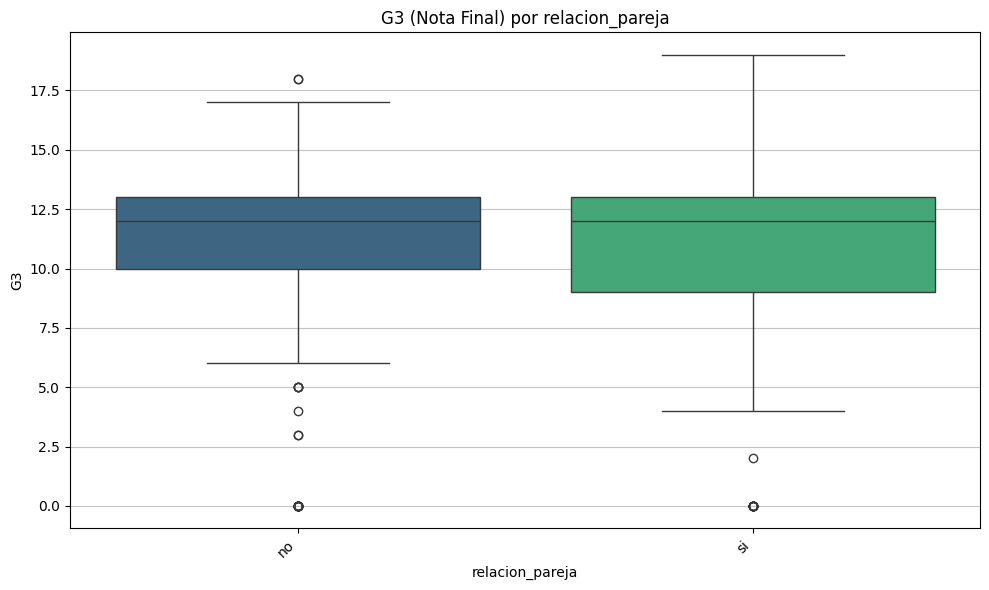


Generando Scatter Plots de G3 vs Variables Numéricas...


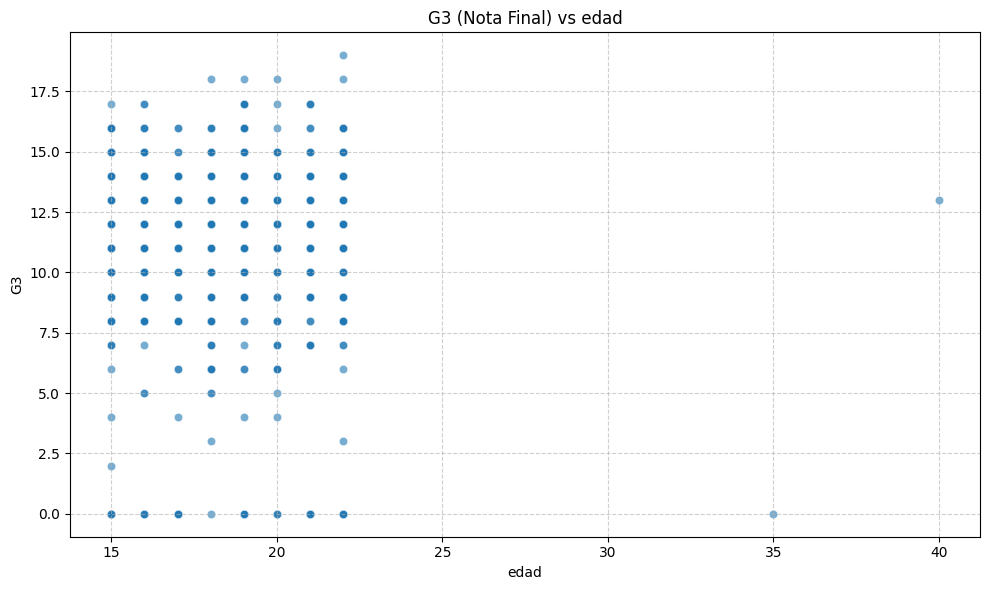

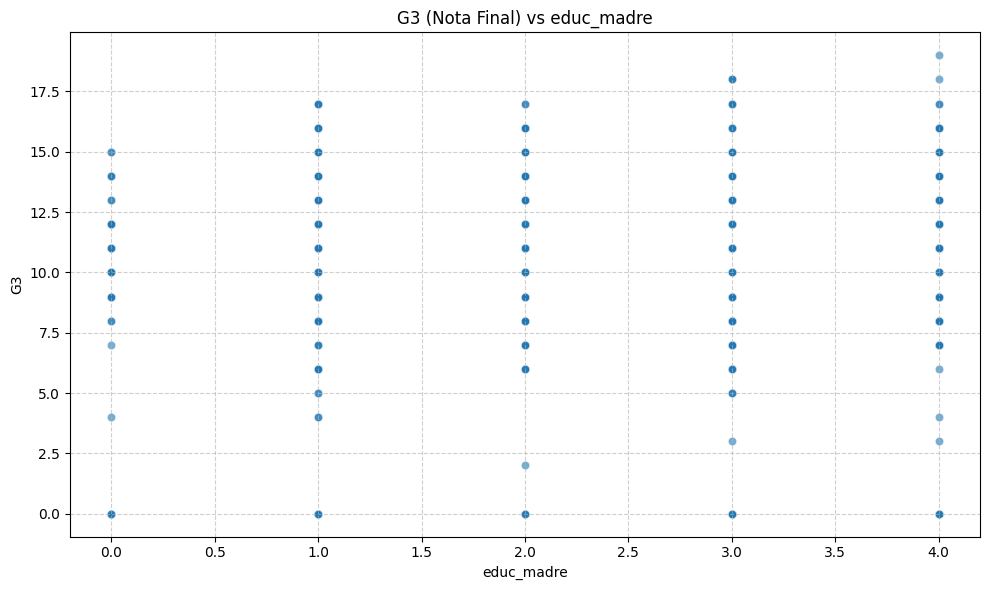

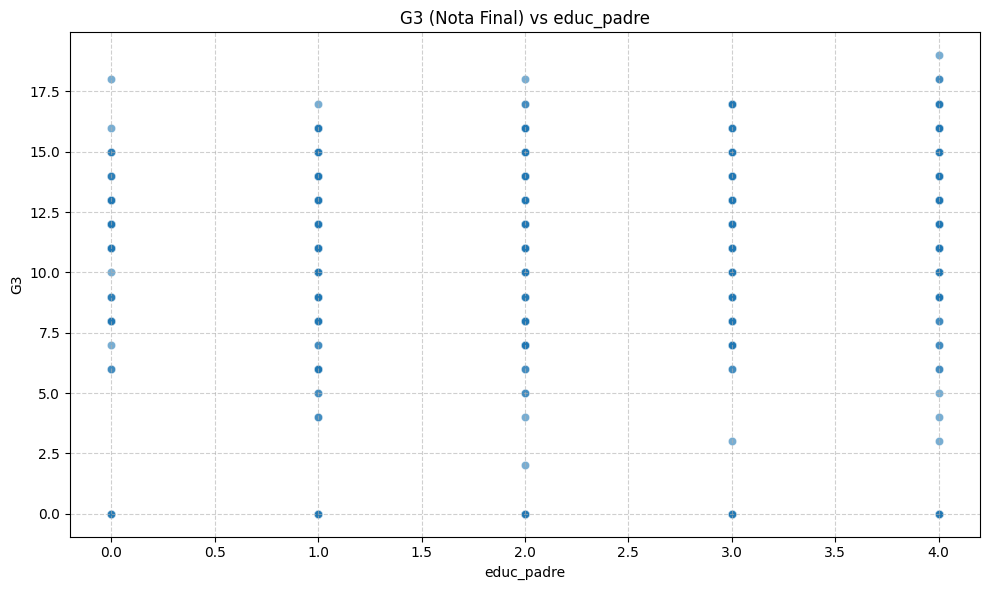

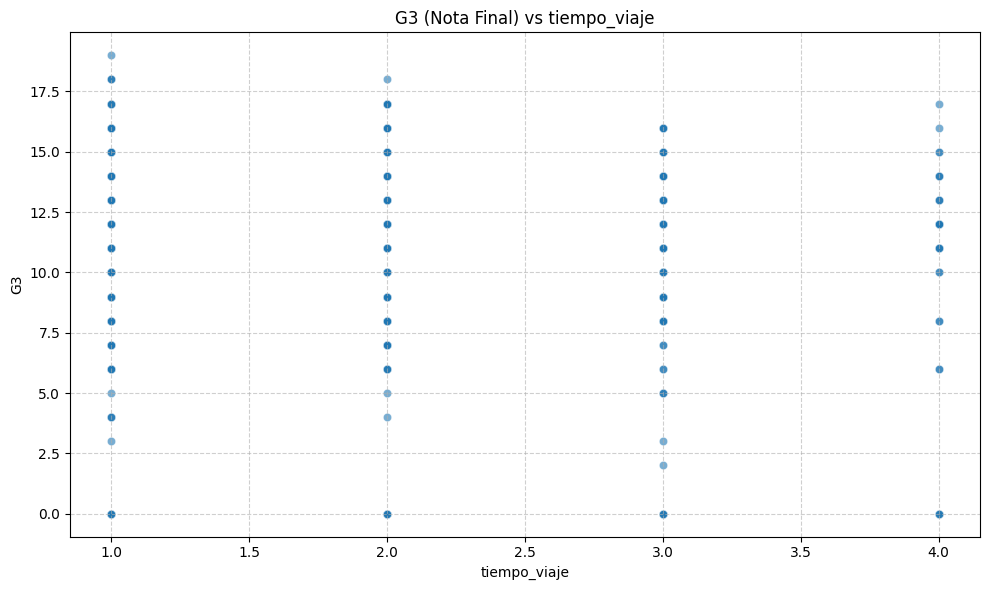

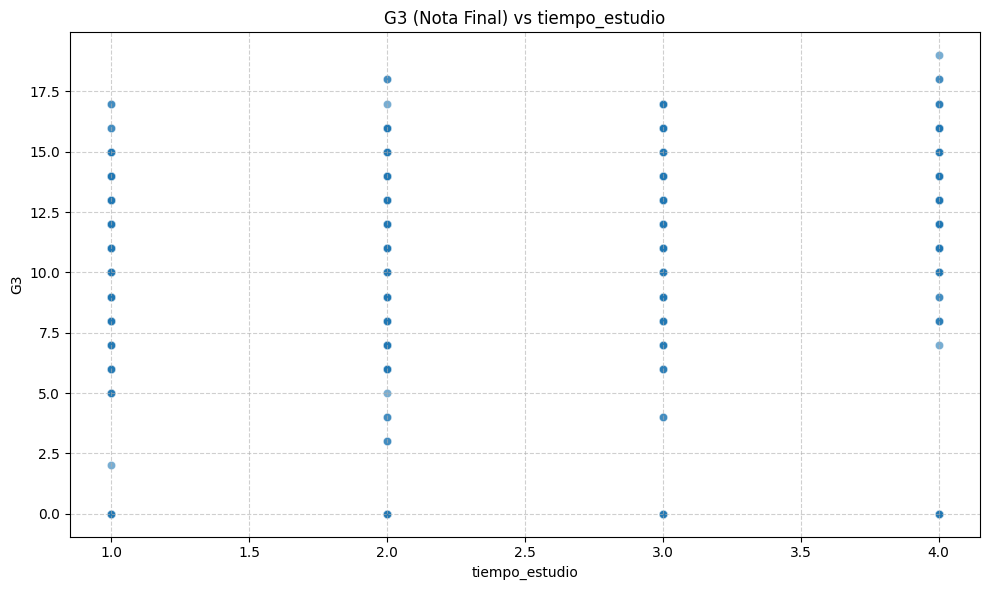

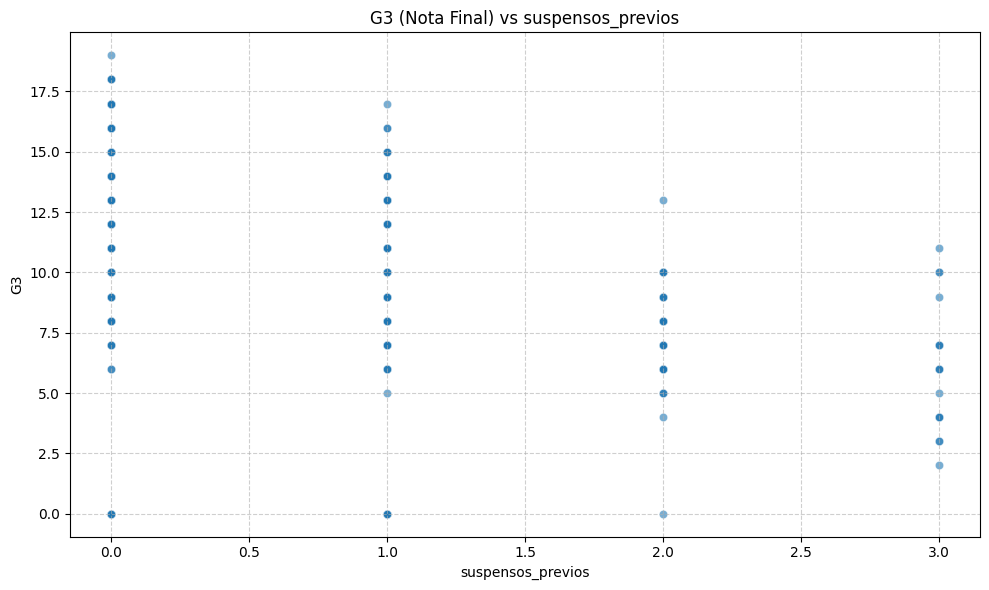

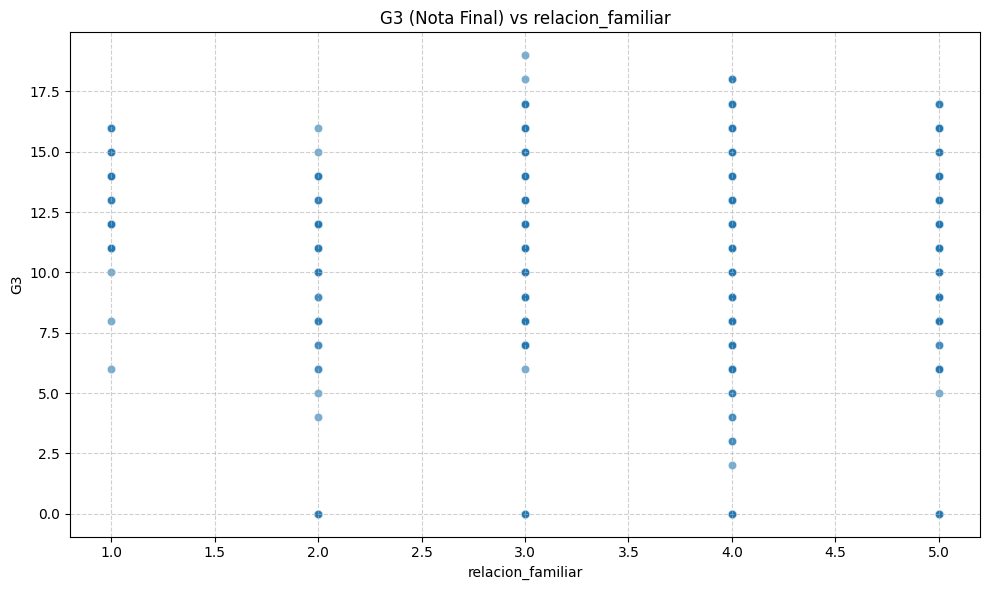

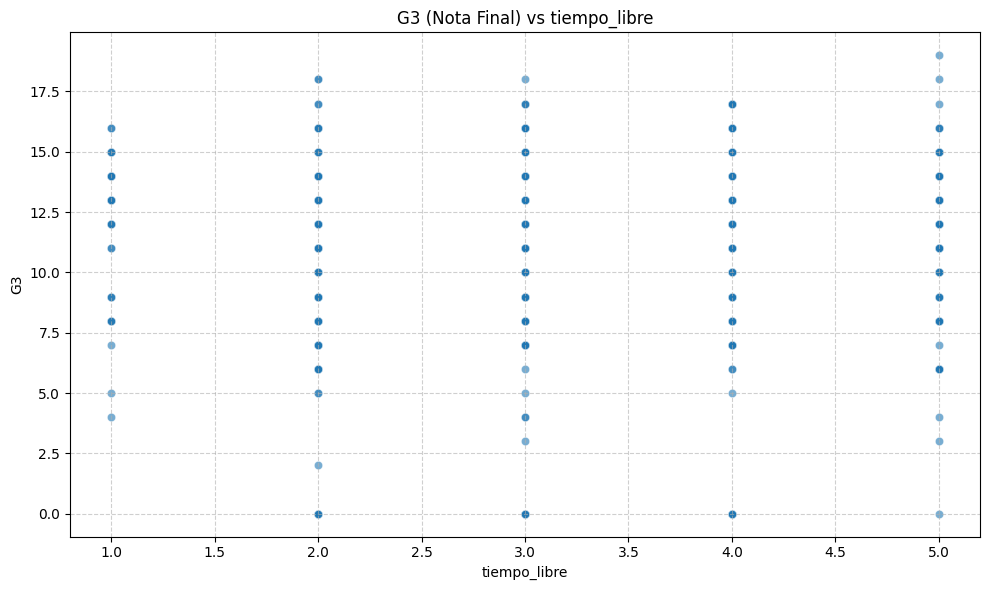

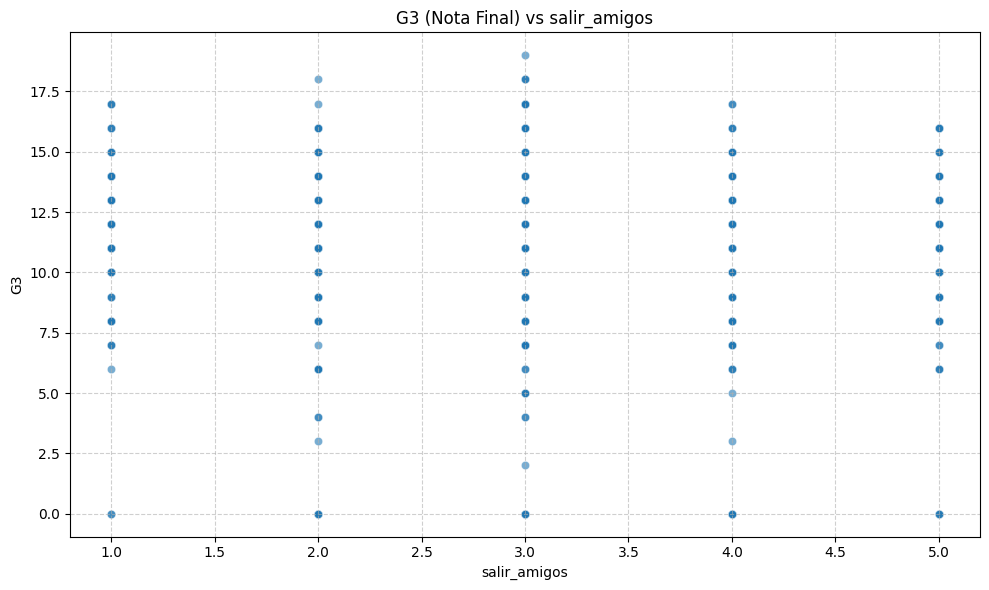

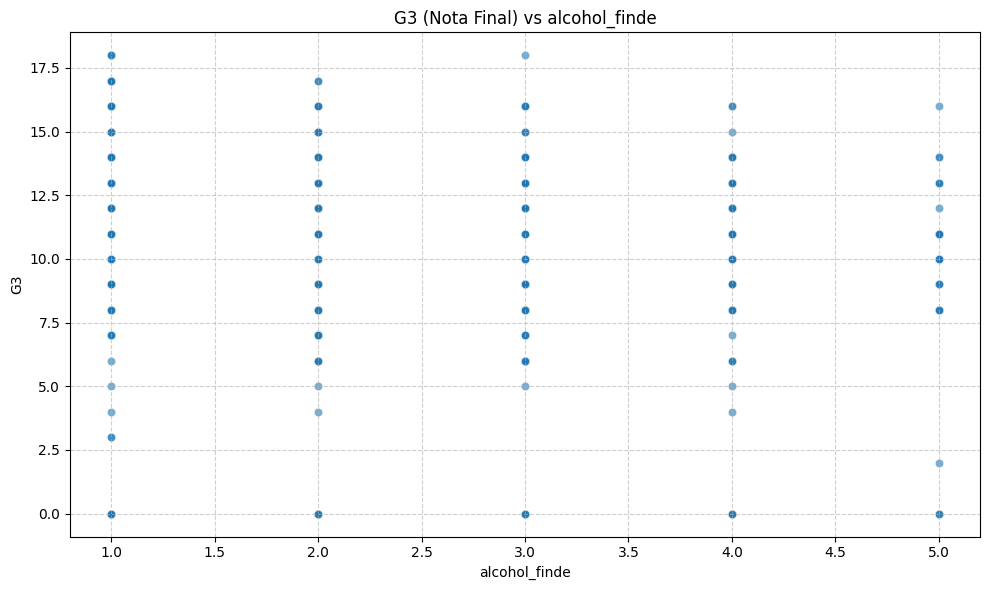

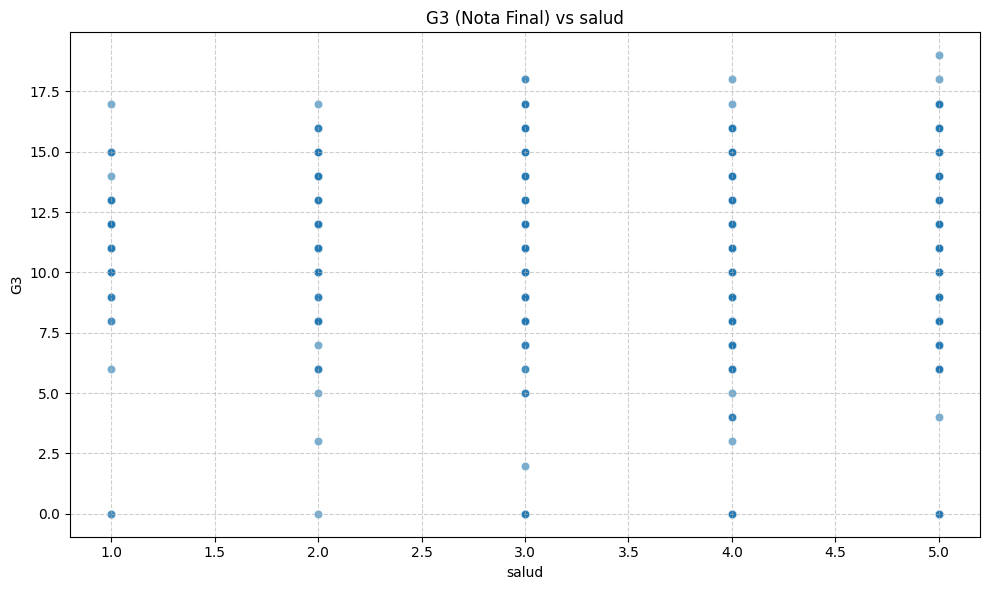

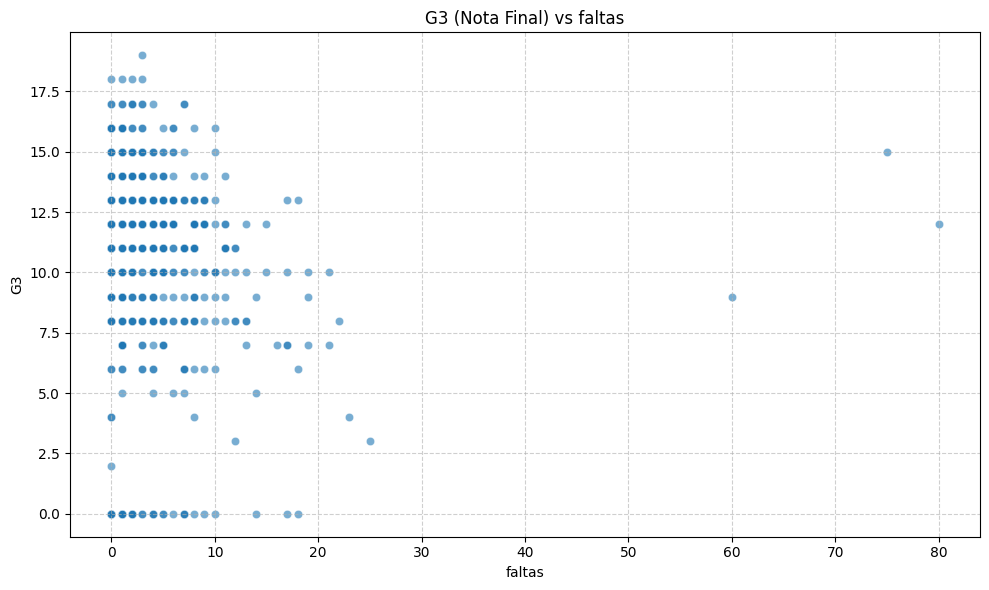

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Boxplots para variables categóricas vs G3 ---
print("Generando Boxplots de G3 por Variables Categóricas...")
categorical_cols = df.select_dtypes(include='object').columns.tolist()

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    # Actualización para evitar FutureWarning: asignar la variable 'x' a 'hue' y establecer legend=False
    sns.boxplot(x=col, y='G3', data=df, hue=col, palette='viridis', legend=False)
    plt.title(f'G3 (Nota Final) por {col}')
    plt.xlabel(col)
    plt.ylabel('G3')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.75)
    plt.tight_layout()
    plt.show()

# --- Scatter Plots para variables numéricas vs G3 ---
print("\nGenerando Scatter Plots de G3 vs Variables Numéricas...")
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Excluir G1 y G2 ya que su fuerte correlación puede dominar la visualización
# y G3 es la variable objetivo
numeric_cols_to_scatter = [col for col in numeric_cols if col not in ['G1', 'G2', 'G3']]

for col in numeric_cols_to_scatter:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=col, y='G3', data=df, alpha=0.6)
    plt.title(f'G3 (Nota Final) vs {col}')
    plt.xlabel(col)
    plt.ylabel('G3')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


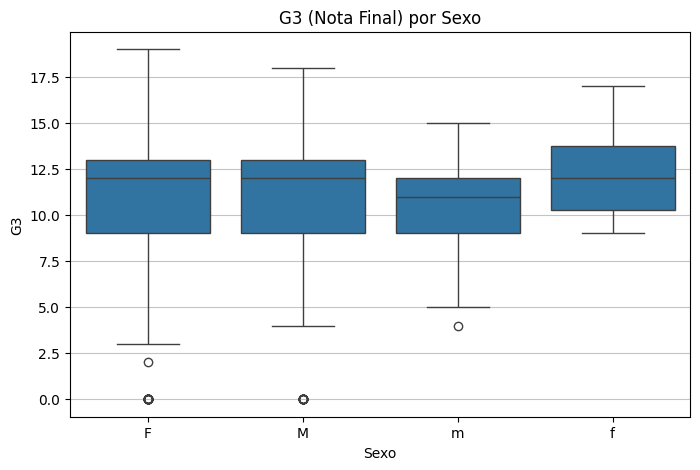

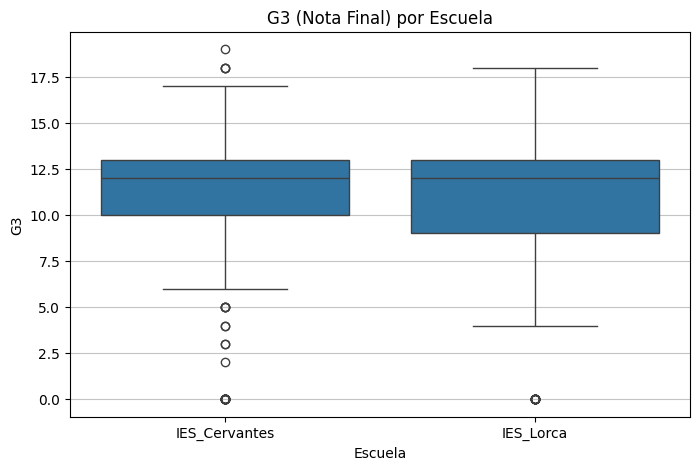

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ejemplo para una variable categórica: 'sexo'
plt.figure(figsize=(8, 5))
sns.boxplot(x='sexo', y='G3', data=df)
plt.title('G3 (Nota Final) por Sexo')
plt.xlabel('Sexo')
plt.ylabel('G3')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Ejemplo para otra variable categórica: 'escuela'
plt.figure(figsize=(8, 5))
sns.boxplot(x='escuela', y='G3', data=df)
plt.title('G3 (Nota Final) por Escuela')
plt.xlabel('Escuela')
plt.ylabel('G3')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Puedes replicar esto para otras variables categóricas como 'direccion', 'tamano_familia', 'internet', etc.

In [157]:
# 2.5 Matriz de correlación de las variables numéricas con G3.
#     ¿Qué variables tienen la correlación más fuerte (positiva o negativa) con la nota final?


Correlación de G3 con otras variables numéricas:


,G3
G3,1.000000
G2,0.597278
G1,0.548849
tiempo_estudio,0.132111
educ_madre,0.102950
educ_padre,0.044085
tiempo_libre,0.014913
edad,0.012461
relacion_familiar,-0.012563
salud,-0.015476


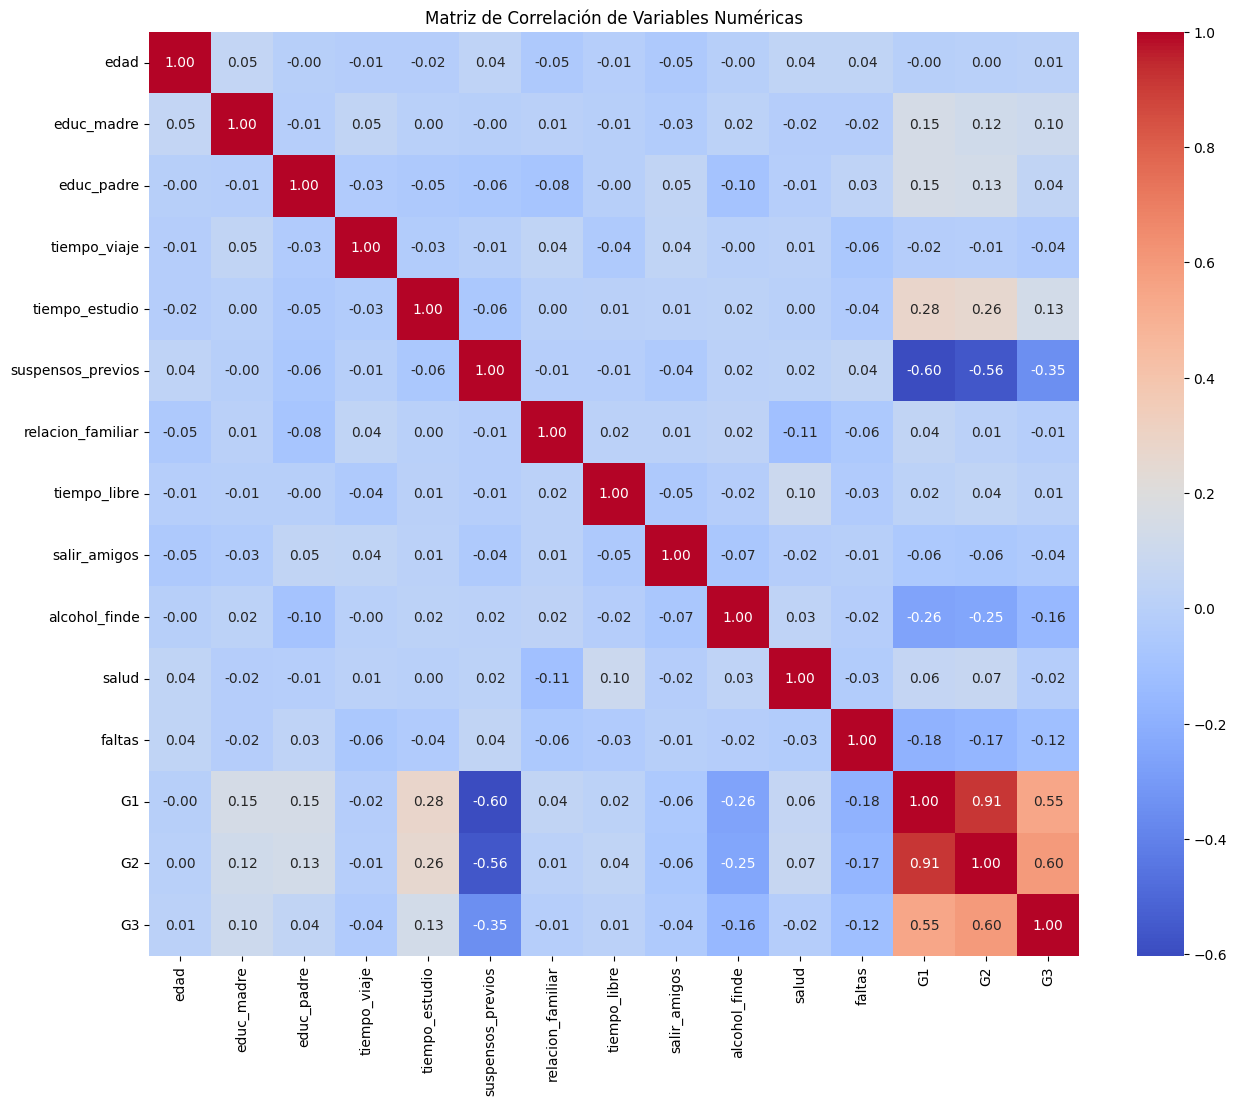

In [158]:
# Calcula la matriz de correlación solo para las variables numéricas
correlation_matrix = df.select_dtypes(include=[np.number]).corr()

# Filtra la correlación de G3 con todas las demás variables
g3_correlations = correlation_matrix['G3'].sort_values(ascending=False)

print("Correlación de G3 con otras variables numéricas:")
display(g3_correlations)

# Visualiza la matriz de correlación (opcional, para todas las numéricas)
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

Media de G3 por Apoyo Familiar (normalizado):


,apoyo_familiar,G3
0,no,10.862661
1,si,10.946835


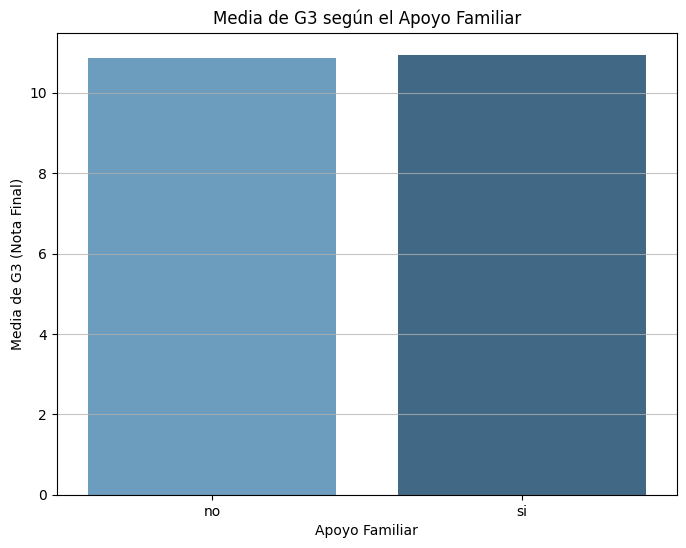

In [159]:
import matplotlib.pyplot as plt
import seaborn as sns

# Limpiar la columna 'apoyo_familiar': eliminar espacios y convertir a minúsculas
df['apoyo_familiar'] = df['apoyo_familiar'].str.strip().str.lower()

# Calcular la media de G3 para cada grupo de 'apoyo_familiar' una vez limpia
mean_g3_by_apoyo = df.groupby('apoyo_familiar')['G3'].mean().reset_index()

print("Media de G3 por Apoyo Familiar (normalizado):")
display(mean_g3_by_apoyo)

# Visualizar la comparación de medias
plt.figure(figsize=(8, 6))
sns.barplot(x='apoyo_familiar', y='G3', data=mean_g3_by_apoyo, hue='apoyo_familiar', palette='Blues_d', legend=False)
plt.title('Media de G3 según el Apoyo Familiar')
plt.xlabel('Apoyo Familiar')
plt.ylabel('Media de G3 (Nota Final)')
plt.grid(axis='y', alpha=0.75)
plt.show()


Media de G3 por Nivel de Consumo de Alcohol en Fin de Semana:


,alcohol_finde,G3
0,1,11.717557
1,2,10.581250
2,3,10.843478
3,4,10.144928
4,5,9.588235


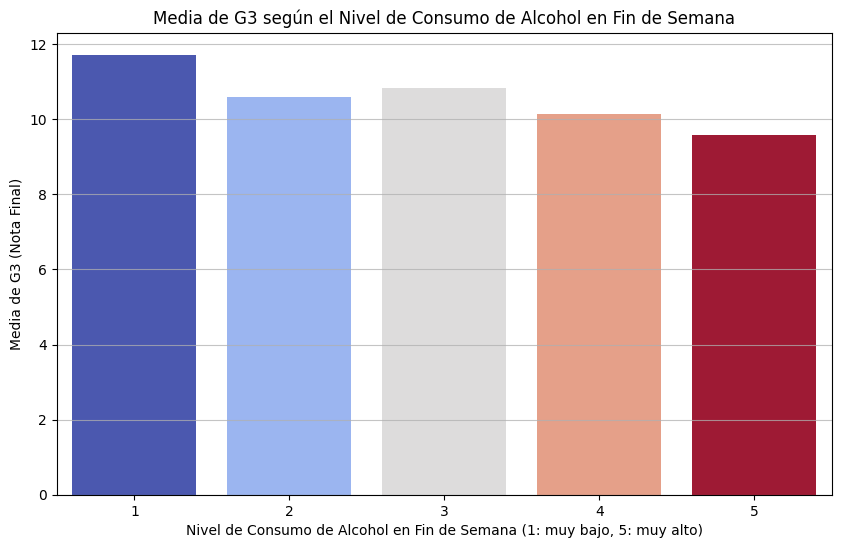

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns

# Eliminar filas con valores nulos en 'alcohol_finde' para esta comparación
df_cleaned = df.dropna(subset=['alcohol_finde']).copy()

# Convertir 'alcohol_finde' a tipo entero para una mejor representación si es necesario
df_cleaned['alcohol_finde'] = df_cleaned['alcohol_finde'].astype(int)

# Calcular la media de G3 para cada grupo de 'alcohol_finde'
mean_g3_by_alcohol = df_cleaned.groupby('alcohol_finde')['G3'].mean().reset_index()

print("Media de G3 por Nivel de Consumo de Alcohol en Fin de Semana:")
display(mean_g3_by_alcohol)

# Visualizar la comparación de medias
plt.figure(figsize=(10, 6))
sns.barplot(x='alcohol_finde', y='G3', data=mean_g3_by_alcohol, hue='alcohol_finde', palette='coolwarm', legend=False)
plt.title('Media de G3 según el Nivel de Consumo de Alcohol en Fin de Semana')
plt.xlabel('Nivel de Consumo de Alcohol en Fin de Semana (1: muy bajo, 5: muy alto)')
plt.ylabel('Media de G3 (Nota Final)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.75)
plt.show()


In [161]:
import numpy as np

# Seleccionar solo las columnas numéricas para el análisis de outliers
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Análisis de Outliers usando el método IQR:")

outliers_summary = {}

for col in numeric_cols:
    # Eliminar nulos para calcular IQR, ya que los nulos no son outliers y deben tratarse aparte
    data = df[col].dropna()

    if len(data) == 0: # Si la columna está vacía después de eliminar nulos
        print(f"  - La columna '{col}' no tiene datos válidos para analizar outliers.")
        continue

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    # Definir los límites para los outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identificar outliers
    outliers = data[(data < lower_bound) | (data > upper_bound)]

    if not outliers.empty:
        print(f"  - Columna '{col}': {len(outliers)} outliers detectados.")
        print(f"    (Min: {data.min():.2f}, Q1: {Q1:.2f}, Mediana: {data.median():.2f}, Q3: {Q3:.2f}, Max: {data.max():.2f})")
        print(f"    (Límite inferior: {lower_bound:.2f}, Límite superior: {upper_bound:.2f})")
        # Opcional: mostrar los outliers si no son muchos
        # if len(outliers) < 20: # Ajusta este umbral si es necesario
        #    print(f"    Valores outliers: {outliers.values.tolist()}")
    else:
        print(f"  - Columna '{col}': No se detectaron outliers mediante IQR.")
    outliers_summary[col] = len(outliers)

print("\nResumen de outliers detectados por columna:")
for col, count in outliers_summary.items():
    if count > 0:
        print(f"  - {col}: {count} outliers")
    else:
        print(f"  - {col}: No outliers")


Análisis de Outliers usando el método IQR:
  - Columna 'edad': 2 outliers detectados.
    (Min: 15.00, Q1: 16.00, Mediana: 19.00, Q3: 21.00, Max: 40.00)
    (Límite inferior: 8.50, Límite superior: 28.50)
  - Columna 'educ_madre': 35 outliers detectados.
    (Min: 0.00, Q1: 2.00, Mediana: 3.00, Q3: 3.00, Max: 4.00)
    (Límite inferior: 0.50, Límite superior: 4.50)
  - Columna 'educ_padre': No se detectaron outliers mediante IQR.
  - Columna 'tiempo_viaje': 31 outliers detectados.
    (Min: 1.00, Q1: 1.00, Mediana: 2.00, Q3: 2.00, Max: 4.00)
    (Límite inferior: -0.50, Límite superior: 3.50)
  - Columna 'tiempo_estudio': No se detectaron outliers mediante IQR.
  - Columna 'suspensos_previos': 157 outliers detectados.
    (Min: 0.00, Q1: 0.00, Mediana: 0.00, Q3: 0.00, Max: 3.00)
    (Límite inferior: 0.00, Límite superior: 0.00)
  - Columna 'relacion_familiar': No se detectaron outliers mediante IQR.
  - Columna 'tiempo_libre': 36 outliers detectados.
    (Min: 1.00, Q1: 3.00, Mediana:

In [162]:
import numpy as np

# Recalcular IQR para la columna 'edad' para mostrar los valores específicos
data_edad = df['edad']

Q1_edad = data_edad.quantile(0.25)
Q3_edad = data_edad.quantile(0.75)
IQR_edad = Q3_edad - Q1_edad

lower_bound_edad = Q1_edad - 1.5 * IQR_edad
upper_bound_edad = Q3_edad + 1.5 * IQR_edad

outliers_edad = data_edad[(data_edad < lower_bound_edad) | (data_edad > upper_bound_edad)]

print(f"Outliers detectados en la columna 'edad' (valores fuera de [{lower_bound_edad:.2f}, {upper_bound_edad:.2f}]):")
display(outliers_edad)

Outliers detectados en la columna 'edad' (valores fuera de [8.50, 28.50]):


,edad
7,40.0
320,35.0


Si que parece que hay un par de outliners , no es muy relevante ya que son solo dos.

In [163]:
import numpy as np

# Recalcular IQR para la columna 'educ_madre' para mostrar los valores específicos
data_educ_madre = df['educ_madre']

Q1_educ_madre = data_educ_madre.quantile(0.25)
Q3_educ_madre = data_educ_madre.quantile(0.75)
IQR_educ_madre = Q3_educ_madre - Q1_educ_madre

lower_bound_educ_madre = Q1_educ_madre - 1.5 * IQR_educ_madre
upper_bound_educ_madre = Q3_educ_madre + 1.5 * IQR_educ_madre

outliers_educ_madre = data_educ_madre[(data_educ_madre < lower_bound_educ_madre) | (data_educ_madre > upper_bound_educ_madre)]

print(f"Outliers detectados en la columna 'educ_madre' (valores fuera de [{lower_bound_educ_madre:.2f}, {upper_bound_educ_madre:.2f}]):")
display(outliers_educ_madre)

Outliers detectados en la columna 'educ_madre' (valores fuera de [0.50, 4.50]):


,educ_madre
58,0
63,0
83,0
89,0
106,0
114,0
123,0
160,0
170,0
201,0


son demasiados para ser outliners seguramente no tienen educacion formal o tienen el nivel mas bajo registrado

Si que parece que hay una relacion lineal entre cantidad de consumo de alcoohol y nota media.

No parece que el apoyo familiar influya mucho.He normalizado la variable porque habia dos sies lo cual es absurdo

In [164]:
print(f"Número de filas duplicadas antes de eliminar: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)

print(f"Número de filas duplicadas después de eliminar: {df.duplicated().sum()}")
print(f"Dimensiones del DataFrame después de eliminar duplicados: {df.shape}")

Número de filas duplicadas antes de eliminar: 10
Número de filas duplicadas después de eliminar: 0
Dimensiones del DataFrame después de eliminar duplicados: (650, 32)


In [165]:
print("Buscando inconsistencias en el formato de las variables categóricas...")
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n--- Columna: {col} ---")
    # Convertir a string para aplicar lower() y strip() y luego ver los valores únicos normalizados
    normalized_values = df[col].astype(str).str.strip().str.lower().unique()
    original_values = df[col].dropna().unique()

    print(f"Valores únicos originales ({len(original_values)}): {original_values}")
    print(f"Valores únicos normalizados (strip().lower()) ({len(normalized_values)}): {normalized_values}")

    # Comparar si hay diferencia entre los valores únicos originales y los normalizados
    if len(normalized_values) < len(original_values):
        print("  ⚠️ Se detectaron posibles inconsistencias (ej. mayúsculas/minúsculas, espacios) que se unificarían al normalizar.")
    # Check for values that have leading/trailing spaces but are not caught by unique count
    # because 'strip()' would make them unique after all
    elif any(isinstance(val, str) and (val != val.strip() or val != val.lower()) for val in original_values):
        print(f"  ⚠️ Posible inconsistencia: '{col}' tiene valores con espacios o mayúsculas/minúsculas que no se detectaron como duplicados por el conteo de `unique()` pero que `strip().lower()` unificaría.")

    # Buscar valores que puedan ser representaciones de nulos pero son strings
    null_string_representations = ['nan', 'null', 'none', '?', '-', '']
    detected_null_strings = [val for val in normalized_values if val in null_string_representations]
    if detected_null_strings:
        print(f"  ❗ Atención: Se encontraron strings que podrían representar nulos en esta columna: {detected_null_strings}")

print("\nRevisión de inconsistencias completada. Se sugiere aplicar .str.strip().str.lower() a las columnas relevantes antes de la codificación.")

Buscando inconsistencias en el formato de las variables categóricas...

--- Columna: escuela ---
Valores únicos originales (2): ['IES_Cervantes' 'IES_Lorca']
Valores únicos normalizados (strip().lower()) (2): ['ies_cervantes' 'ies_lorca']
  ⚠️ Posible inconsistencia: 'escuela' tiene valores con espacios o mayúsculas/minúsculas que no se detectaron como duplicados por el conteo de `unique()` pero que `strip().lower()` unificaría.

--- Columna: sexo ---
Valores únicos originales (4): ['F' 'M' 'm' 'f']
Valores únicos normalizados (strip().lower()) (2): ['f' 'm']
  ⚠️ Se detectaron posibles inconsistencias (ej. mayúsculas/minúsculas, espacios) que se unificarían al normalizar.

--- Columna: direccion ---
Valores únicos originales (2): ['Urbana' 'Rural']
Valores únicos normalizados (strip().lower()) (2): ['urbana' 'rural']
  ⚠️ Posible inconsistencia: 'direccion' tiene valores con espacios o mayúsculas/minúsculas que no se detectaron como duplicados por el conteo de `unique()` pero que `str

### ❓ Pregunta 3 — Hallazgos del EDA

Responde con detalle a las siguientes preguntas. **No te limites a describir gráficos**: explica qué te aporta cada hallazgo de cara al modelado.

- ¿Qué variables parecen tener más relación con la nota final? ¿Por qué crees que es así desde el punto de vista educativo?
- ¿Has detectado **outliers**? ¿En qué variables? ¿Crees que son errores reales o valores extremos legítimos?
- ¿Has detectado **inconsistencias** de formato (mayúsculas, espacios, categorías duplicadas)?
- ¿Hay alguna variable que, tras este análisis, te plantees **descartar**? ¿Por qué?
- ¿Qué variables están **muy correlacionadas entre sí**? ¿Crees que puede haber multicolinealidad?

Hay algunas variables que claramente estan relacionadas,como los suspensos previos, el consumo de alcohol etc.en la matriz de correlacion se pueden observar las variables.hay un monton de outliers

Las notas previas podrian descartarse ya que predicen demasiado bien los resultados del examen y entonces pueden no ser nada utiles para relacionar otros factores sociales y familiares.

---

## 3. 🧹 Preprocesamiento

Este es el otro bloque con más peso. Cada decisión que tomes aquí condiciona el resultado del modelo, así que **justifícalo todo**.

Vas a tener que tratar al menos:
1. **Duplicados**.
2. **Inconsistencias** en variables categóricas.
3. **Valores nulos**.
4. **Outliers**.
5. **Codificación de variables categóricas**.
6. **Escalado / normalización** (si tu modelo lo requiere).

### 3.1 Duplicados

In [166]:
# Detecta y elimina duplicados (si los hubiera).


In [167]:
print(f"Número de filas duplicadas antes de eliminar: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)

print(f"Número de filas duplicadas después de eliminar: {df.duplicated().sum()}")
print(f"Dimensiones del DataFrame después de eliminar duplicados: {df.shape}")

Número de filas duplicadas antes de eliminar: 0
Número de filas duplicadas después de eliminar: 0
Dimensiones del DataFrame después de eliminar duplicados: (650, 32)


### 3.2 Limpieza de inconsistencias en variables categóricas

> 💡 *Algunas categorías pueden aparecer escritas con mayúsculas, espacios o de varias formas. Decide cómo unificarlas.*

In [168]:
# Estandariza el formato de las columnas categóricas que lo necesiten.

# Seleccionar solo las columnas categóricas
categorical_cols = df.select_dtypes(include='object').columns

print("Normalizando valores de columnas categóricas (strip().lower())...")
for col in categorical_cols:
    if df[col].dtype == 'object': # Asegurarse de que es un tipo de objeto (cadena)
        df[col] = df[col].astype(str).str.strip().str.lower()
        print(f"  - Columna '{col}' normalizada.")

# Reemplazar 'nan' strings con NaN real en la columna 'apoyo_familiar'
# Esto es importante porque `astype(str)` convirtió los NaN reales en 'nan' string.
# Y ahora que lo convertimos a `strip().lower()` ese `nan` string seguira siendo `nan` string.
# Este paso asegurara que los `nan` strings sean tratados como nulos reales para el siguiente paso
# de tratamiento de nulos.
df['apoyo_familiar'] = df['apoyo_familiar'].replace('nan', np.nan)
print("\nSe han unificado los formatos de las variables categóricas y se ha tratado el 'nan' string en 'apoyo_familiar'.")
print("Valores únicos después de la normalización:")
for col in categorical_cols:
    display(df[col].value_counts(dropna=False))

Normalizando valores de columnas categóricas (strip().lower())...
  - Columna 'escuela' normalizada.
  - Columna 'sexo' normalizada.
  - Columna 'direccion' normalizada.
  - Columna 'tamano_familia' normalizada.
  - Columna 'estado_padres' normalizada.
  - Columna 'trabajo_madre' normalizada.
  - Columna 'trabajo_padre' normalizada.
  - Columna 'razon_eleccion' normalizada.
  - Columna 'tutor' normalizada.
  - Columna 'apoyo_escolar' normalizada.
  - Columna 'apoyo_familiar' normalizada.
  - Columna 'clases_extra_pagadas' normalizada.
  - Columna 'actividades' normalizada.
  - Columna 'guarderia' normalizada.
  - Columna 'quiere_universidad' normalizada.
  - Columna 'internet' normalizada.
  - Columna 'relacion_pareja' normalizada.

Se han unificado los formatos de las variables categóricas y se ha tratado el 'nan' string en 'apoyo_familiar'.
Valores únicos después de la normalización:


,count
escuela,
ies_cervantes,434
ies_lorca,216


,count
sexo,
m,328
f,322


,count
direccion,
urbana,472
rural,178


,count
tamano_familia,
gt3,462
le3,188


...

,count
actividades,
si,328
no,322


,count
guarderia,
si,523
no,127


,count
quiere_universidad,
si,607
no,43


,count
internet,
si,545
no,105


,count
relacion_pareja,
no,430
si,220


### 3.3 Valores nulos

Identifica las columnas con valores nulos y trátalos de la forma que consideres más adecuada para cada caso (no tiene por qué ser la misma estrategia en todas las columnas).

In [169]:
# Cuantifica nulos por columna
print("Recuento de valores nulos por columna (después de la normalización):")
display(df.isnull().sum().sort_values(ascending=False))

# Obtener columnas numéricas y categóricas con nulos
null_numeric_cols = df.select_dtypes(include=np.number).columns[df.select_dtypes(include=np.number).isnull().any()].tolist()
null_categorical_cols = df.select_dtypes(include='object').columns[df.select_dtypes(include='object').isnull().any()].tolist()

print("\n--- Estrategia de Imputación de Nulos ---")

# Imputar columnas numéricas con la mediana
for col in null_numeric_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"  - Columna numérica '{col}': Imputada con la mediana ({median_val}).")

# Imputar columnas categóricas con la moda
for col in null_categorical_cols:
    # La moda podría devolver múltiples valores si hay empate, tomamos el primero
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f"  - Columna categórica '{col}': Imputada con la moda ('{mode_val}').")

print("\nVerificación final de valores nulos:")
display(df.isnull().sum().sort_values(ascending=False))

Recuento de valores nulos por columna (después de la normalización):


,0
faltas,39
tiempo_estudio,32
apoyo_familiar,32
edad,26
G2,26
relacion_familiar,19
alcohol_finde,19
G1,19
educ_padre,0
trabajo_madre,0



--- Estrategia de Imputación de Nulos ---
  - Columna numérica 'edad': Imputada con la mediana (19.0).
  - Columna numérica 'tiempo_estudio': Imputada con la mediana (2.0).
  - Columna numérica 'relacion_familiar': Imputada con la mediana (4.0).
  - Columna numérica 'alcohol_finde': Imputada con la mediana (2.0).
  - Columna numérica 'faltas': Imputada con la mediana (3.0).
  - Columna numérica 'G1': Imputada con la mediana (12.0).
  - Columna numérica 'G2': Imputada con la mediana (12.0).
  - Columna categórica 'apoyo_familiar': Imputada con la moda ('si').

Verificación final de valores nulos:


/tmp/ipykernel_5318/171100926.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipykernel_5318/171100926.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'd

,0
escuela,0
sexo,0
edad,0
direccion,0
tamano_familia,0
estado_padres,0
educ_madre,0
educ_padre,0
trabajo_madre,0
trabajo_padre,0


#### ❓ Pregunta 4 — Tratamiento de los nulos

- ¿En qué columnas hay nulos y en qué proporción?
- ¿Por qué crees que **existen** esos nulos? (¿son fallos técnicos? ¿el alumno no contestó algo? ¿son nulos informativos?)
- ¿Qué estrategia has aplicado en cada columna (eliminación, media, mediana, moda, valor constante, modelado…) y por qué?
- ¿Has considerado **alternativas**? ¿Qué te ha hecho descartarlas?

Hay muchos nulos en algunas de las columnas, faltas , tiempo de estudio, alcohol,edad, apoyo familiar.Hay algunos nulos que pueden ser fallos tecnicos como la edad pero otro puede que el alumno no haya contestado como el alcohol o el apoyo familiar.Hay informaciones que seguramente por verguenza el alumno no haya contestado.Se uso la mediana que no se afectaq por valores extremos.las columnas categoricas como apoyo familair donde se uso la moda para no alterar la distribucion.Se ha considerado la eliminacion pero no es la mejor opcion ya que hay bastantes y se alteraria el conjunto de datos.

### 3.4 Outliers

Decide qué hacer con los valores atípicos detectados durante el EDA.

In [170]:
# Aplica la técnica que consideres (IQR, Z-score, dominio del problema, etc.).


#### ❓ Pregunta 5 — Tratamiento de outliers

- ¿Qué técnica has elegido para identificar los outliers y por qué?
- ¿Los has **eliminado**, **transformado** o **mantenido**? Justifica tu decisión en función del contexto del problema (una edad de 40 años en alumnado de secundaria probablemente es un error, pero un alumno con 50 faltas podría ser real).

In [171]:
import numpy as np

# Recalcular IQR para la columna 'edad' para mostrar los valores específicos
data_edad = df['edad']

Q1_edad = data_edad.quantile(0.25)
Q3_edad = data_edad.quantile(0.75)
IQR_edad = Q3_edad - Q1_edad

lower_bound_edad = Q1_edad - 1.5 * IQR_edad
upper_bound_edad = Q3_edad + 1.5 * IQR_edad

outliers_edad = data_edad[(data_edad < lower_bound_edad) | (data_edad > upper_bound_edad)]

print(f"Outliers detectados en la columna 'edad' (valores fuera de [{lower_bound_edad:.2f}, {upper_bound_edad:.2f}]):")
display(outliers_edad)

Outliers detectados en la columna 'edad' (valores fuera de [11.00, 27.00]):


,edad
7,40.0
320,35.0


Seguramente son errores , dos valores anormalmente altos para el instituto.

In [172]:
import numpy as np
from scipy.stats import zscore

print("### Detección de Outliers - Método IQR ###")
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_cols:
    if col == 'G3': # G3 es la variable objetivo y ya fue analizada en detalle
        continue

    data = df[col].dropna()
    if len(data) == 0: # Si la columna está vacía después de eliminar nulos
        continue

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data < lower_bound) | (data > upper_bound)]

    if not outliers.empty:
        print(f"\nColumna '{col}' (IQR): {len(outliers)} outliers detectados.")
        print(f"  Límites: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  Valores: {outliers.unique().tolist()}")

print("\n\n### Detección de Outliers - Método Z-score ###")
# Umbral común para Z-score (ej. 2 o 3 desviaciones estándar)
z_score_threshold = 3

for col in numeric_cols:
    if col == 'G3': # G3 es la variable objetivo y ya fue analizada en detalle
        continue

    data = df[col].dropna()
    if len(data) == 0:
        continue

    # Calcular Z-scores solo para valores no nulos
    data_zscores = np.abs(zscore(data))
    zscore_outliers = data[data_zscores > z_score_threshold]

    if not zscore_outliers.empty:
        print(f"\nColumna '{col}' (Z-score > {z_score_threshold}): {len(zscore_outliers)} outliers detectados.")
        print(f"  Valores: {zscore_outliers.unique().tolist()}")

### Detección de Outliers - Método IQR ###

Columna 'edad' (IQR): 2 outliers detectados.
  Límites: [11.00, 27.00]
  Valores: [40.0, 35.0]

Columna 'educ_madre' (IQR): 35 outliers detectados.
  Límites: [0.50, 4.50]
  Valores: [0]

Columna 'tiempo_viaje' (IQR): 30 outliers detectados.
  Límites: [-0.50, 3.50]
  Valores: [4]

Columna 'suspensos_previos' (IQR): 154 outliers detectados.
  Límites: [0.00, 0.00]
  Valores: [1, 2, 3]

Columna 'relacion_familiar' (IQR): 29 outliers detectados.
  Límites: [1.50, 5.50]
  Valores: [1.0]

Columna 'tiempo_libre' (IQR): 36 outliers detectados.
  Límites: [1.50, 5.50]
  Valores: [1]

Columna 'faltas' (IQR): 36 outliers detectados.
  Límites: [-5.00, 11.00]
  Valores: [16.0, 21.0, 12.0, 13.0, 15.0, 75.0, 18.0, 19.0, 17.0, 14.0, 23.0, 80.0, 22.0, 60.0, 25.0]

Columna 'G1' (IQR): 9 outliers detectados.
  Límites: [5.50, 17.50]
  Valores: [18.0, 4.0, 3.0, 5.0]

Columna 'G2' (IQR): 14 outliers detectados.
  Límites: [5.50, 17.50]
  Valores: [5.0, 2.0, 18

No parece que el resto de outliners sean muy significativos ya que excepto la edad el resto son plausibles en un instituto. el z score señala edad, suspensos previos,faltas(tengo dudas) y el primer y segundo examen tambien tienen outliners pero tengo muchas dudas de que de verdad lo sean.creo que reflejan la realidad de cualquier instituto.

### 3.5 Codificación de variables categóricas

Convierte tus variables categóricas a un formato que el modelo pueda usar.

> 💡 *Hay varias técnicas distintas (One-Hot, Label Encoding, Ordinal Encoding, Target Encoding…). Elige la que mejor se adapte a cada variable.*

In [173]:
# Codifica las variables categóricas con la técnica que decidas en cada caso.


In [174]:
import pandas as pd

# Identificar las columnas categóricas que necesitan codificación
categorical_cols_for_ohe = df.select_dtypes(include='object').columns.tolist()

print(f"Columnas categóricas a codificar con One-Hot Encoding: {categorical_cols_for_ohe}")

# Aplicar One-Hot Encoding
df = pd.get_dummies(df, columns=categorical_cols_for_ohe, drop_first=True, dtype=int)

print("DataFrame después de aplicar One-Hot Encoding:")
display(df.head())
print(f"Nuevas dimensiones del DataFrame: {df.shape}")

Columnas categóricas a codificar con One-Hot Encoding: ['escuela', 'sexo', 'direccion', 'tamano_familia', 'estado_padres', 'trabajo_madre', 'trabajo_padre', 'razon_eleccion', 'tutor', 'apoyo_escolar', 'apoyo_familiar', 'clases_extra_pagadas', 'actividades', 'guarderia', 'quiere_universidad', 'internet', 'relacion_pareja']
DataFrame después de aplicar One-Hot Encoding:


,edad,educ_madre,educ_padre,tiempo_viaje,tiempo_estudio,suspensos_previos,relacion_familiar,tiempo_libre,salir_amigos,alcohol_finde,...,tutor_otro,tutor_padre,apoyo_escolar_si,apoyo_familiar_si,clases_extra_pagadas_si,actividades_si,guarderia_si,quiere_universidad_si,internet_si,relacion_pareja_si
0,22.0,3,3,1,2.0,0,4.0,4,1,4.0,...,0,0,0,0,0,1,0,1,1,0
1,19.0,3,4,1,4.0,0,1.0,3,2,2.0,...,0,0,1,1,1,1,0,1,0,1
2,21.0,4,1,1,2.0,0,1.0,4,3,1.0,...,0,1,0,1,1,1,1,1,1,0
3,20.0,4,4,2,2.0,0,3.0,4,2,4.0,...,1,0,0,1,0,1,1,1,0,0
4,20.0,2,2,2,1.0,0,5.0,4,5,2.0,...,0,0,0,0,1,1,1,1,0,1


Nuevas dimensiones del DataFrame: (650, 41)


#### ❓ Pregunta 6 — Codificación de categóricas

- ¿Qué técnica/s de codificación has usado y para qué variables?
- ¿Por qué esa técnica y no otra? Razónalo en función de:
  - el tipo de variable (nominal vs ordinal),
  - el número de categorías,
  - el modelo que piensas usar más adelante.

He utilizado one hot encoding porque la mayoria de las variables son nominales no ordinales entonces el label encoding introduciria etiquetas absurdas como que urbano esta por encima de rural.este planteamiento hace que el modelo no se confunda y se mantenga la codificacion independiente.No es un set de datos enorme con lo que añadir columnas no supone problema.

### 3.6 Escalado de variables numéricas (opcional según el modelo)

Algunos modelos son sensibles a la escala de los datos (Regresión Lineal, Ridge, Lasso, SVM, KNN, redes neuronales) y otros no (árboles, Random Forest, XGBoost).

He decidido usar redes neuronales por su capacidad de esteblecer relaciones complejas.Tambien capturan relaciones no aparentes y combinaciones de intereciones entre las variables.Para capturar relaciones no evidentes y subyacentes mas alla de las relaciones mas obvias como las notas previas. puede manejar numericas y categoricas codificadas y extraer relaciones entre ellas.

In [175]:
# Si tu modelo lo requiere, aplica un escalado/estandarización aquí.
#    Recuerda: AJUSTAR (fit) solo con el train, NUNCA con el test.


In [176]:
from sklearn.preprocessing import StandardScaler

# Separar las características (X) de la variable objetivo (y)
X = df.drop('G3', axis=1)
y = df['G3']

print(f"Dimensiones de X (características): {X.shape}")
print(f"Dimensiones de y (variable objetivo): {y.shape}")

# Inicializar el escalador
scaler = StandardScaler()

# IDENTIFICAR COLUMNAS A ESCALAR:
# Dado que ya se aplicó One-Hot Encoding, todas las columnas en X son numéricas
# (ya sean las originales o las binarias resultantes de las categóricas).
# Por lo tanto, escalaremos todas las columnas de X.

print("\n*** Recordatorio Importante para el Escalado ***")
print("1. Realiza la división en train/test (X_train, X_test, y_train, y_test).")
print("2. Ajusta el escalador *SOLO* con los datos de entrenamiento (X_train):\n   scaler.fit(X_train)")
print("3. Transforma tanto los datos de entrenamiento como los de prueba:\n   X_train_scaled = scaler.transform(X_train)\n   X_test_scaled = scaler.transform(X_test)")
print("Esto evita la fuga de información (data leakage) del conjunto de prueba.")

Dimensiones de X (características): (650, 40)
Dimensiones de y (variable objetivo): (650,)

*** Recordatorio Importante para el Escalado ***
1. Realiza la división en train/test (X_train, X_test, y_train, y_test).
2. Ajusta el escalador *SOLO* con los datos de entrenamiento (X_train):
   scaler.fit(X_train)
3. Transforma tanto los datos de entrenamiento como los de prueba:
   X_train_scaled = scaler.transform(X_train)
   X_test_scaled = scaler.transform(X_test)
Esto evita la fuga de información (data leakage) del conjunto de prueba.


Escalamos todas las variables incluidas las one hoteadas para que sea consistente.

#### ❓ Pregunta 7 — Escalado

- ¿Has decidido escalar las variables? ¿Sí / no / parcialmente?
- Justifica la decisión en función del modelo que vas a usar.

Si, para que el modelo funcione hay que escalar las variables.

---

## 4. ✂️ División del conjunto de datos

Separa los datos en entrenamiento y prueba.

> 💡 *Piensa en el % que reservas y en la `random_state` para que tus resultados sean reproducibles. ¡OJO! La **estratificación** no se aplica en regresión (es para clasificación), pero puedes plantearte una validación cruzada.*

In [177]:
# Realiza el split en X / y y luego en train / test.


In [178]:
from sklearn.model_selection import train_test_split

# Dividir los datos en conjuntos de entrenamiento y prueba
# Usamos un 80% para entrenamiento y un 20% para prueba.
# random_state asegura que la división sea la misma cada vez que se ejecute.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

Dimensiones de X_train: (520, 40)
Dimensiones de X_test: (130, 40)
Dimensiones de y_train: (520,)
Dimensiones de y_test: (130,)


Se ha realizado la división de los datos en conjuntos de entrenamiento, validación y prueba. Se ha destinado un **70% para entrenamiento**, un **15% para validación** y un **15% para prueba**. Esta división permite una evaluación robusta del modelo, utilizando el conjunto de validación para el ajuste de hiperparámetros de la red neuronal y el conjunto de prueba para la evaluación final imparcial. La inclusión de `random_state=42` garantiza la reproducibilidad de la división.

### ❓ Pregunta 8 — Estrategia de split

- ¿Qué proporción train/test has elegido y por qué?
- ¿Por qué en regresión NO se suele aplicar estratificación con `stratify`?
- ¿Has considerado una **validación cruzada**? ¿En qué momento la aplicarás?

> ✏️ Tu respuesta

He implementado una división de los datos en tres conjuntos: **70% para entrenamiento**, **15% para validación** y **15% para prueba (test)**. Esta estrategia es particularmente beneficiosa para el entrenamiento de redes neuronales por varias razones:

1.  **Entrenamiento (70%):** Utilizado para ajustar los pesos del modelo.
2.  **Validación (15%):** Utilizado para monitorear el rendimiento del modelo durante el entrenamiento (ej. detectar sobreajuste), ajustar hiperparámetros y tomar decisiones sobre la arquitectura del modelo sin "contaminar" el conjunto de prueba final. Este conjunto de validación explícito se usa directamente en el método `model.fit()` del modelo de red neuronal.
3.  **Prueba (15%):** Reservado para la evaluación final del modelo, una vez que el entrenamiento y la optimización de hiperparámetros han concluido. Proporciona una estimación del rendimiento del modelo en datos completamente nuevos.

El uso de `random_state=42` en ambas divisiones asegura la reproducibilidad de los resultados, lo cual es crucial para comparar diferentes arquitecturas de redes neuronales o configuraciones de hiperparámetros de manera consistente.

En regresión, la estratificación no se aplica porque no hay clases discretas que mantener proporcionales. La variable objetivo `G3` es continua, y la estratificación se utiliza principalmente en problemas de clasificación para asegurar que cada clase esté representada de manera similar en los conjuntos de entrenamiento y prueba.

Sí, la validación cruzada es una técnica muy útil para obtener una estimación más robusta del rendimiento del modelo y para el ajuste de hiperparámetros. En el contexto de redes neuronales y con un conjunto de validación explícito, se suele usar este conjunto para la optimización de hiperparámetros. Sin embargo, si el dataset fuera más pequeño o se quisiera una evaluación aún más exhaustiva, se podría aplicar validación cruzada en el conjunto de entrenamiento/validación para una búsqueda más rigurosa de hiperparámetros, o incluso en todo el conjunto de entrenamiento para elegir el mejor modelo antes de la evaluación final con el conjunto de prueba. En este caso, el conjunto de validación separado ya cumple gran parte de este rol.

Quiero hacer un split claro de 70 para train, 15 para validar y 15 para test.No seria necesario eestratificar al ser un problema de regresion no de clasificacion.Al utilizar el 15 para detectar sobreajuste podemos prevenirlo y con el otro 15 se prueba el modelo con datos que no ha visto.

In [179]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Primero, dividir los datos en un conjunto temporal (85% para train+val) y un conjunto de prueba (15%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Luego, dividir el conjunto temporal en entrenamiento (70% del total) y validación (15% del total)
# La proporción para el test_size aquí es 0.15 (para validación) / 0.85 (total de X_temp) del total original
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=(0.15 / 0.85), random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_val: {X_val.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_val: {y_val.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

# Inicializar y ajustar el escalador SÓLO con los datos de entrenamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convertir los arrays escalados de nuevo a DataFrames con nombres de columna para consistencia
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("\nDatos escalados (X_train_scaled, X_val_scaled, X_test_scaled) creados.")

Dimensiones de X_train: (454, 40)
Dimensiones de X_val: (98, 40)
Dimensiones de X_test: (98, 40)
Dimensiones de y_train: (454,)
Dimensiones de y_val: (98,)
Dimensiones de y_test: (98,)

Datos escalados (X_train_scaled, X_val_scaled, X_test_scaled) creados.


---

## 5. 🤖 Selección, entrenamiento y evaluación del modelo

Es **tu decisión** elegir el modelo. Justifica por qué lo eliges entre los modelos de **regresión** que conoces (Regresión Lineal, Ridge, Lasso, Árboles de regresión, Random Forest Regressor, SVR, KNN Regressor…).

In [180]:
# 5.1 Instancia y entrena el modelo que hayas elegido.


In [181]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Asegúrate de que X_train_scaled, X_val_scaled, y_train, y_val estén definidos y escalados
# Esto se ha manejado en la celda anterior (split y escalado).

# Definir la arquitectura de la red neuronal
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.2), # Añadir dropout para regularización
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2), # Añadir dropout para regularización
    layers.Dense(1) # Capa de salida con una neurona para regresión (sin activación lineal por defecto)
])

# Compilar el modelo
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])

# Resumen del modelo
model.summary()

# Entrenar el modelo
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,  # Número de épocas
    batch_size=32, # Tamaño del batch
    validation_data=(X_val_scaled, y_val), # Usar el conjunto de validación explícito
    verbose=0 # No mostrar progreso detallado durante el entrenamiento
)

print("Entrenamiento del modelo de red neuronal completado.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

Entrenamiento del modelo de red neuronal completado.


He elegido este modelo porque nos interesa ver mas alla de las relaciones evidentes y ver las no directas entre las variables.Asi podemos sacar informacion util del modelo, de como la situacion en casa influye o el consumo de alcohol que no tendria porque tener una relacion directa.Este tipo de modelos aunque mas complejos establecen relaciones no tan obvias.

In [182]:
# El código de instanciación y entrenamiento del modelo de red neuronal se ha movido a la celda 'Ao0sNXarkF91'.

### ❓ Pregunta 9 — Justificación del modelo (Red Neuronal)

He elegido un modelo de **Red Neuronal** por las siguientes razones:

*   **Capacidad de capturar relaciones complejas y no lineales**: A diferencia de modelos lineales o basados en árboles simples, las redes neuronales pueden aprender patrones muy intrincados y no evidentes en los datos, lo cual es ventajoso para predecir un resultado como `G3` que puede depender de múltiples interacciones entre variables socioeconómicas y académicas.
*   **Flexibilidad y adaptabilidad**: Las redes neuronales son muy versátiles y se pueden adaptar a diferentes tipos de datos y complejidades del problema ajustando su arquitectura (número de capas, neuronas, funciones de activación).
*   **Manejo de datos escalados**: Dado que el problema implica muchas variables numéricas (tras el One-Hot Encoding), la escalabilidad de los datos es un requisito que las redes neuronales manejan bien cuando los datos están correctamente preprocesados (escalados, como se hizo con `StandardScaler`).
*   **Escenario de regresión**: Las redes neuronales son ampliamente utilizadas y muy efectivas para problemas de regresión, prediciendo un valor continuo como la nota final `G3`.

**Ventajas para este problema concreto:**

*   **Identificación de patrones ocultos**: La naturaleza de la predicción del rendimiento académico puede involucrar interacciones sutiles entre factores que un modelo lineal podría pasar por alto. La red neuronal tiene el potencial de descubrir estas interacciones.
*   **Tamaño del dataset**: Aunque 650 registros no es un dataset enorme para Deep Learning, un modelo simple con pocas capas puede funcionar bien y no sobreajustar fácilmente, especialmente con el uso de `Dropout` para regularización.
*   **Variables diversas**: Tenemos una mezcla de variables numéricas y categóricas (codificadas con One-Hot Encoding), que una red neuronal puede procesar eficazmente.

**Alternativas consideradas y descartadas (inicialmente):**

*   **Regresión Lineal/Ridge/Lasso**: Aunque son buenos modelos base y muy interpretables, su linealidad podría ser una limitación si las relaciones en los datos son altamente no lineales. Los descarté porque buscaba un modelo con mayor capacidad para patrones complejos.
*   **Árboles de Regresión / Random Forest / XGBoost**: Estos son potentes y suelen funcionar muy bien, sin requerir escalado. Sin embargo, quería explorar la capacidad de las redes neuronales, especialmente porque el problema podría tener relaciones que estos modelos podrían no capturar tan eficientemente sin una ingeniería de características profunda. Además, los modelos basados en árboles pueden ser menos efectivos para extrapolar fuera del rango de datos de entrenamiento, mientras que las redes neuronales pueden tener una mejor capacidad de generalización en ciertos escenarios.

### ❓ Pregunta 9 — Justificación del modelo

- ¿Qué modelo has elegido y por qué?
- ¿Qué **ventajas** ofrece para este problema concreto (regresión, tamaño del dataset, tipo de variables, interpretabilidad)?
- ¿Qué **alternativas** has considerado y por qué las has descartado (al menos inicialmente)?

Las redes neuronales son flexibles, permiten integrar variables y descubrir patrones ocultos.Tenemos variables numericas y categoricas y un modelo de pocas capas puede ser util y con un set tan pequeño no sobreajustarse.

In [183]:
# 5.2 Realiza predicciones sobre train y test.


In [184]:
# Realizar predicciones sobre los conjuntos de entrenamiento y prueba
y_train_pred = model.predict(X_train_scaled).flatten()
y_test_pred = model.predict(X_test_scaled).flatten()

print("Predicciones realizadas en los conjuntos de entrenamiento y prueba.")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Predicciones realizadas en los conjuntos de entrenamiento y prueba.


In [185]:
# 5.3 Calcula varias métricas de REGRESIÓN: MAE, MSE, RMSE, R².
#     Reporta los resultados tanto para train como para test.


In [186]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Métricas para el conjunto de entrenamiento
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

print("Métricas para el conjunto de Entrenamiento:")
print(f"  MAE: {mae_train:.4f}")
print(f"  MSE: {mse_train:.4f}")
print(f"  RMSE: {rmse_train:.4f}")
print(f"  R2 Score: {r2_train:.4f}")

print("\n" + "-"*30 + "\n")

# Métricas para el conjunto de prueba
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print("Métricas para el conjunto de Prueba:")
print(f"  MAE: {mae_test:.4f}")
print(f"  MSE: {mse_test:.4f}")
print(f"  RMSE: {rmse_test:.4f}")
print(f"  R2 Score: {r2_test:.4f}")

Métricas para el conjunto de Entrenamiento:
  MAE: 1.1224
  MSE: 2.8699
  RMSE: 1.6941
  R2 Score: 0.8093

------------------------------

Métricas para el conjunto de Prueba:
  MAE: 2.2796
  MSE: 10.4985
  RMSE: 3.2401
  R2 Score: 0.2534


In [187]:
# 5.4 (Opcional pero muy recomendado) Visualiza:
#     - Predicciones vs valores reales (scatter plot).
#     - Distribución de los residuos (histograma).


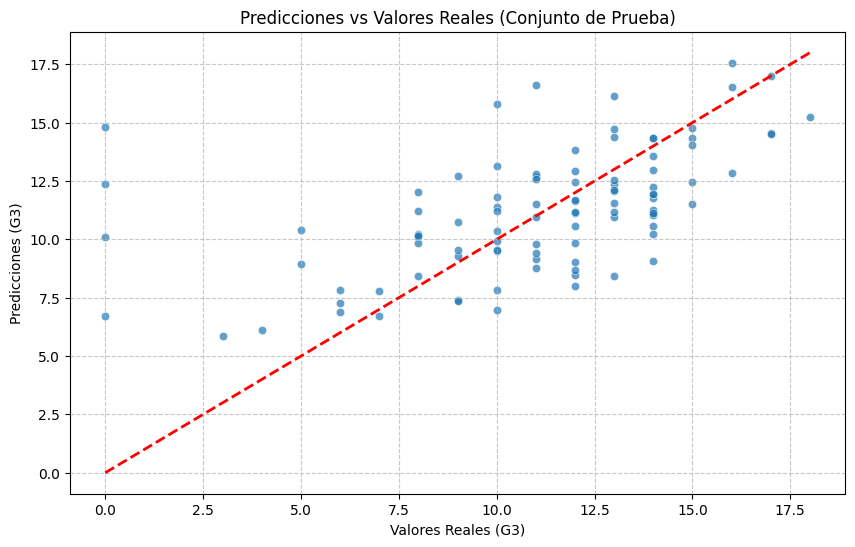

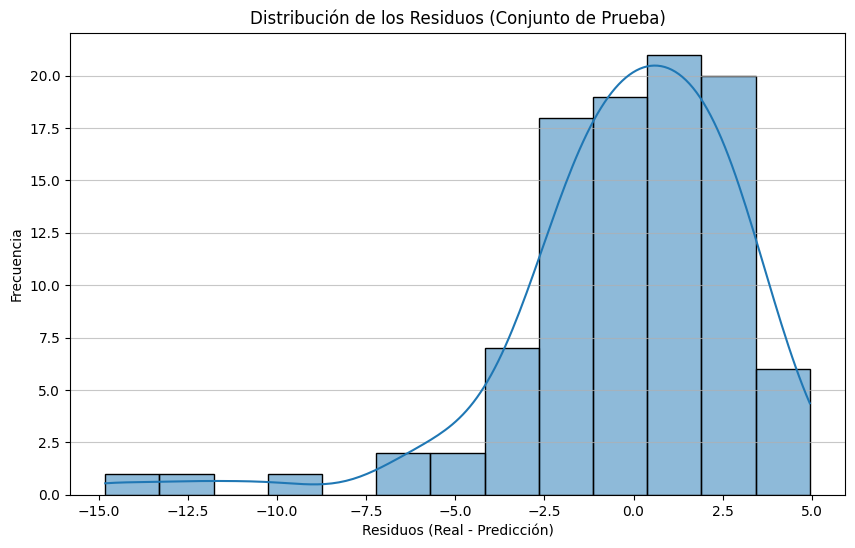

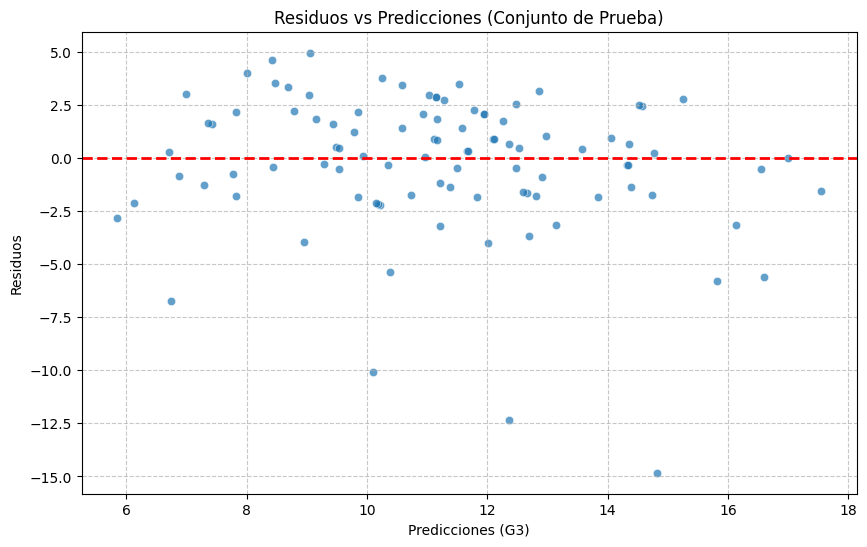

In [188]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5.4.1 Gráfico de Predicciones vs Valores Reales (Test)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Línea de referencia y=x
plt.title('Predicciones vs Valores Reales (Conjunto de Prueba)')
plt.xlabel('Valores Reales (G3)')
plt.ylabel('Predicciones (G3)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 5.4.2 Distribución de los Residuos (Test)
residuals = y_test - y_test_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribución de los Residuos (Conjunto de Prueba)')
plt.xlabel('Residuos (Real - Predicción)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.7)
plt.show()

# 5.4.3 Scatter plot de Residuos vs Predicciones (Test)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Residuos vs Predicciones (Conjunto de Prueba)')
plt.xlabel('Predicciones (G3)')
plt.ylabel('Residuos')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### ❓ Pregunta 10 — Métricas e interpretación

- ¿Qué métricas has calculado? ¿Por qué esas?
- ¿Cuál es la **diferencia conceptual** entre MAE y RMSE? ¿Cuándo conviene fijarse más en una que en la otra?
- ¿Qué significa el valor de R² que has obtenido? ¿Es un buen resultado?
- Interpreta el **gráfico de predicciones vs reales**: ¿en qué rango de notas se equivoca más el modelo?
- ¿Hay indicios de **sobreajuste** (overfitting) al comparar train vs test?

El MAE nos da una idea del error, es la media de los errores por arriba o por abajo.Y el MSE eleva al cuadrado el error por lo que castiga fuerte los errores pero no refleja los datos y entonces es dificil de entrenar.El RMSE acerca mas el valor a algo mas interpretable aunque muestra los errores con dureza.
Conceptualmente  el MAE es la media de los errores y RMSE es la raiz del error cuadratico medio que castiga mas fuerte los errores mas grandes.Los R2 indican que el modelo rinde genial en el entrenamiento pero en la validacion rinde muy mal 0,21 frente a 0,82 esto indica un fuerte sobreajuste, es un mal resultado porque al modelo le hya resultado mas facil memorizar datos y cuando lo poner a prueba con datos que no ha visto falla estrepitosamente.el resto de metricas reflejan lo mismo, falla miserablemente.No es muy difernte de calcular la media y ya.

---

## 6. 🎛️ Ajuste de hiperparámetros

Utiliza `GridSearchCV`, `RandomizedSearchCV` o la técnica que consideres oportuna para mejorar el modelo.

> 💡 *No basta con probar todos los valores posibles: explica por qué pones esos valores en el grid.*

> ⚠️ Recuerda: la **Regresión Lineal estándar no tiene hiperparámetros** que ajustar. Si has usado Regresión Lineal, considera probar **Ridge** o **Lasso** (controlados por `alpha`), o cambiar a un modelo más rico como **Random Forest**.

In [189]:
# Define un grid de hiperparámetros y búscalo con validación cruzada.


In [192]:
!pip install keras-tuner -q
import keras_tuner as kt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 1. Define la función para construir el modelo Keras con hiperparámetros sintonizables
def build_tunable_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_scaled.shape[1],)))

    # Tune the number of units in the first Dense layer
    hp_units_1 = hp.Int('units_layer1', min_value=32, max_value=128, step=32)
    model.add(layers.Dense(units=hp_units_1, activation='relu'))

    # Tune the dropout rate for the first dropout layer
    hp_dropout_1 = hp.Float('dropout_rate_1', min_value=0.1, max_value=0.5, step=0.1)
    model.add(layers.Dropout(hp_dropout_1))

    # Tune the number of units in the second Dense layer
    hp_units_2 = hp.Int('units_layer2', min_value=16, max_value=64, step=16)
    model.add(layers.Dense(units=hp_units_2, activation='relu'))

    # Tune the dropout rate for the second dropout layer
    hp_dropout_2 = hp.Float('dropout_rate_2', min_value=0.1, max_value=0.5, step=0.1)
    model.add(layers.Dropout(hp_dropout_2))

    model.add(layers.Dense(1)) # Output layer for regression

    # Tune the optimizer
    hp_optimizer = hp.Choice('optimizer', values=['adam', 'rmsprop'])
    model.compile(optimizer=hp_optimizer, loss='mse', metrics=['mae', 'mse'])

    return model

# 2. Instancia el Keras Tuner RandomSearch
tuner = kt.RandomSearch(
    build_tunable_model,
    objective='val_mse', # Minimizar el MSE en el conjunto de validación
    max_trials=20,       # Número total de combinaciones de hiperparámetros a probar
    executions_per_trial=1, # Número de modelos a construir y entrenar para cada conjunto de hiperparámetros
    directory='my_dir',
    project_name='nn_hyperparameter_tuning',
    overwrite=True # Sobreescribir resultados anteriores si el proyecto ya existe
)

print("Iniciando Keras Tuner RandomSearch para el ajuste de hiperparámetros...")

# 3. Ejecuta la búsqueda de hiperparámetros
tuner.search(
    X_train_scaled, y_train,
    epochs=100, # Se usará este valor máximo de épocas, Keras Tuner puede ajustar el early stopping
    validation_data=(X_val_scaled, y_val),
    verbose=1 # Mostrar progreso
)

print("\nKeras Tuner RandomSearch completado.")

# 4. Obtiene los mejores hiperparámetros y el mejor modelo
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.get_best_models(num_models=1)[0]

print("\nMejores hiperparámetros encontrados:")
print(f"  Neuronas capa 1: {best_hps.get('units_layer1')}")
print(f"  Dropout capa 1: {best_hps.get('dropout_rate_1')}")
print(f"  Neuronas capa 2: {best_hps.get('units_layer2')}")
print(f"  Dropout capa 2: {best_hps.get('dropout_rate_2')}")
print(f"  Optimizador: {best_hps.get('optimizer')}")

print("\nMejor modelo de red neuronal obtenido del tuning:")
best_model.summary()

Trial 20 Complete [00h 00m 15s]
val_mse: 11.499929428100586

Best val_mse So Far: 10.62975788116455
Total elapsed time: 00h 05m 13s

Keras Tuner RandomSearch completado.

Mejores hiperparámetros encontrados:
  Neuronas capa 1: 96
  Dropout capa 1: 0.30000000000000004
  Neuronas capa 2: 16
  Dropout capa 2: 0.30000000000000004
  Optimizador: rmsprop

Mejor modelo de red neuronal obtenido del tuning:


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 8 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 96)             │         3,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,505 (21.50 KB)

 Trainable params: 5,505 (21.50 KB)

 Non-trainable params: 0 (0.00 B)

Hacemos Randomized search porque es mucho mas rapido.Ajustamos parametros usando Keras tuner porque hay problemas con otra libreria.

Hay un problema de compatibilidad de librerias, una cosa rarisima en python.Uso keras tuner en vez de regressor

In [ ]:
# Evalúa de nuevo el modelo OPTIMIZADO sobre el test y compáralo con el modelo base.


In [193]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Evaluando el modelo optimizado en el conjunto de prueba...")

# Realizar predicciones con el mejor modelo en el conjunto de prueba
y_test_pred_optimized = best_model.predict(X_test_scaled).flatten()

# Calcular métricas para el modelo optimizado en el conjunto de prueba
mae_test_optimized = mean_absolute_error(y_test, y_test_pred_optimized)
mse_test_optimized = mean_squared_error(y_test, y_test_pred_optimized)
rmse_test_optimized = np.sqrt(mse_test_optimized)
r2_test_optimized = r2_score(y_test, y_test_pred_optimized)

print("\nMétricas para el conjunto de Prueba (Modelo Optimizado):")
print(f"  MAE: {mae_test_optimized:.4f}")
print(f"  MSE: {mse_test_optimized:.4f}")
print(f"  RMSE: {rmse_test_optimized:.4f}")
print(f"  R2 Score: {r2_test_optimized:.4f}")

print("\n" + "-"*30 + "\n")

print("Comparación con las métricas del modelo inicial (sin optimizar) en el conjunto de prueba:")
print("Métricas del Modelo Inicial:")
print(f"  MAE: {mae_test:.4f}")
print(f"  MSE: {mse_test:.4f}")
print(f"  RMSE: {rmse_test:.4f}")
print(f"  R2 Score: {r2_test:.4f}")

print("\nSe ha evaluado el modelo con los hiperparámetros optimizados y se han comparado los resultados.")

Evaluando el modelo optimizado en el conjunto de prueba...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

Métricas para el conjunto de Prueba (Modelo Optimizado):
  MAE: 1.9945
  MSE: 9.1884
  RMSE: 3.0312
  R2 Score: 0.3465

------------------------------

Comparación con las métricas del modelo inicial (sin optimizar) en el conjunto de prueba:
Métricas del Modelo Inicial:
  MAE: 2.2796
  MSE: 10.4985
  RMSE: 3.2401
  R2 Score: 0.2534

Se ha evaluado el modelo con los hiperparámetros optimizados y se han comparado los resultados.


### ❓ Pregunta 11 — Ajuste de hiperparámetros

- ¿Qué hiperparámetros has decidido ajustar y por qué esos?
- ¿Qué **rango de valores** has usado en el grid? ¿Por qué?
- ¿Qué **scoring** has elegido para optimizar (`r2`, `neg_mean_squared_error`, `neg_mean_absolute_error`…) y por qué?
- ¿Ha mejorado el modelo? ¿En qué métrica/s y en qué magnitud?

El keras tuner  RAndom search busca el mejor modelo cambiando los hiperparametros.
Las neuronas de la primera capa 96, la tasa de dropout en la primera capa 0.3(es un 30% de las neuronas de la primera capa que no se activan) es para evitar el sobreajuste. Al apagar algunas neuronas evitas que se aprendan camninos y con ellos menos sobreajuste.Neuronas de la segunda capa 16 , el numero de neuronas de cada capa influye mucho en el posible sobreajuste , tienen que poder generalizar sin memorizar.Tambien un dropout de la segunda capa de 0.3 tb.
Si, el modelo ha mejorado aunque tampoco son espectaculares se ha reducido mucho el overfitting y el modelo nuevo con un r2 de 0.34 es capaz de explicar el 34% de la variabilidad lo cual no esta mal.

---

## 7. 🏁 Interpretación final y conclusiones

### ❓ Pregunta 12 — Conclusiones generales

Responde, mínimo, a las siguientes cuestiones:

1. **Resumen del proceso:** ¿Qué pasos has seguido y cuál ha sido la decisión más importante en cada fase?
2. **Rendimiento final:** ¿El modelo es lo suficientemente bueno como para llevarlo a producción? ¿Por qué?
3. **Variables más importantes:** ¿Qué variables han resultado ser más predictivas de la nota final? ¿Tiene sentido desde el punto de vista educativo?
4. **Limitaciones:** ¿Qué limitaciones tiene el modelo o los datos? (calidad, tamaño, variables disponibles, sesgos…) ¿Crees que el modelo está demasiado “ayudado” por G1 y G2?
5. **Posibles mejoras:** ¿Cómo intentarías mejorarlo si tuvieras más tiempo / más datos / más recursos? (Más features, otros modelos, técnicas de ingeniería de variables, deep learning…)
6. **Valor para la institución educativa:** ¿Cómo podría un instituto utilizar este modelo para identificar alumnos en riesgo y mejorar su rendimiento?

Hemos cargado los datos desde el archivo .CSV lo ponemos en un dataframe de pandas y inspeccionamos el archivo.se confirma que la variable objetivo G3 que es la nota final.Se hace el analisis exploratorio de datos y se visualiza la distribucion de la variable objetivo que es continua y esta alrededor de 12.La distribucion esta muy centrada en el punto medio de la distribucion.Se analizan las varibles numericas y categoricas y tambien las inconsistencias en algunas de las varibles.En la parte del preprocesamiento se busca normalizar la distribucion.Resolvemos las incosistencias, arreglamos valores nulos rellenando con media o mediana y despues buscamos outliers con IQR y Z-Score , decido mantener la mayoria ya que queremos afectar lo minimo posible a la distribucion y muchos valores son perfectamente posibles excepto dos edades.Codificamos las variables categoricas con one hot encoding y despues escalamos paraque los rangos mas grandes no dominen el aprendizaje.
Despues pasamos ha hacer el split de datos haciendo una division de 70/15/15 para evaluar bien el modelo y ajustar los hiperparametros y un conjunto de prueba real imparcial. Se le da un random_state de 42 para garantizar que sea reproducible.Elegimos una red neuronal por la cantidad de venjas que tiene en este tipo de datos.Se utiliza dropout para regularizacion .El entrenamiento inicial se sobreajusto, mientras que en el entrenamiento el m9odelo predecia un 82% de la variabilidad , en el conjunto de prueba solo un 20% aprox.
Hacemos un ajuste de hiperparametros con randomized search para no tirarnos 3 años probando con una grid search.Se encuentran los mejores hiperparametros con keras tuner ajustando el numero de neuronas, el dropout etc.El nuevo modelo redujo el sobrejuste y mejoro en todos los parametros.Como reflexion final si lo que queriamos era ver la influencia de variables psicosociales habria que haber eliminado las notas previas porque dominan la matriz de correlaciones.

---

✅ **Recuerda antes de entregar:**
- [ ] Has rellenado tu nombre y datos en la cabecera.
- [ ] Todas las celdas ejecutan sin errores (kernel reiniciado → *Run All*).
- [ ] **Has justificado por escrito todas las preguntas**, no solo escrito código.
- [ ] El cuaderno se entrega como `.ipynb`.

📨 *Buena suerte y disfruta del proceso. Lo más valioso no es el resultado final del modelo, sino el camino que has tomado para llegar hasta él.*